In [ ]:
# NOTEBOOK 06 - CONTRASTE DE HIPÓTESIS
'''
En este notebook evaluamos las cuatro hipótesis definidas al inicio del proyecto.  
Utilizamos los datasets ya limpiados y las visualizaciones generadas en notebooks anteriores, ampliando el análisis con nuevas comparaciones, métricas e interpretaciones.

Las hipótesis son:

H1 — La contaminación atmosférica aumenta el impacto en la salud respiratoria**  
Se espera que los años con mayores niveles de contaminación presenten también un aumento en hospitalizaciones y mortalidad respiratoria.

H2 — Las zonas costeras presentan menor contaminación que las zonas de interior**  
La dispersión atmosférica suele ser mejor en áreas cercanas al mar, por lo que se anticipan niveles más bajos en estaciones costeras.

H3 — Las estaciones urbanas y de tráfico presentan mayores niveles de contaminación**  
Las estaciones clasificadas como tráfico y urbano deberían registrar concentraciones más altas que las estaciones rurales o de fondo.

H4 — El ozono (O₃) aumenta en verano debido a procesos fotoquímicos**  
El ozono troposférico depende de la radiación solar, por lo que se espera observar un patrón estacional claro con valores más altos en verano.
'''

'\nEn este notebook evaluamos las cuatro hipótesis definidas al inicio del proyecto.  \nUtilizamos los datasets ya limpiados y las visualizaciones generadas en notebooks anteriores, ampliando el análisis con nuevas comparaciones, métricas e interpretaciones.\n\nLas hipótesis son:\n\n**H1 — La contaminación atmosférica aumenta el impacto en la salud respiratoria**  \nSe espera que los años con mayores niveles de contaminación presenten también un aumento en hospitalizaciones y mortalidad respiratoria.\n\n**H3 — Las estaciones urbanas y de tráfico presentan mayores niveles de contaminación**  \nLas estaciones clasificadas como tráfico y urbano deberían registrar concentraciones más altas que las estaciones rurales o de fondo.\n\n**H2 — Las zonas costeras presentan menor contaminación que las zonas de interior**  \nLa dispersión atmosférica suele ser mejor en áreas cercanas al mar, por lo que se anticipan niveles más bajos en estaciones costeras.\n\n**H4 — El ozono (O₃) aumenta en verano 

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

'''
configuración estética global para los gráficos:
-sns.set(style="whitegrid"): aplica un estilo limpio con fondo cuadriculado, adecuado para análisis exploratorios.
-plt.rcParams["figure.figsize"]: define el tamaño por defecto de todas las figuras (12x6 pulgadas), garantizando visualizaciones legibles y consistentes.
'''

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# cargo los dataset y el merged

df_hospi = pd.read_csv("../data/context_clean/hospitalizations_clean.csv")
df_mortality = pd.read_csv("../data/context_clean/mortality_clean.csv")
df_population = pd.read_csv("../data/context_clean/population_clean.csv")

df_pollutants_stations = pd.read_parquet("../data/integrated/df_pollutants_stations.parquet")


In [35]:
df_hospi.head()

,region,year,hospitalizations
0,ES,2011,518276
1,ES,2012,524962
2,ES,2013,506929
3,ES,2014,531124
4,ES,2015,426914


In [36]:
df_mortality.head()

,region,year,deaths
0,ES,2011,42125
1,ES,2012,47237
2,ES,2013,42444
3,ES,2014,43699
4,ES,2015,51711


In [37]:
df_population.head()

,region,year,population
0,ES,2011,46742697
1,ES,2012,46773055
2,ES,2013,46604197
3,ES,2014,46460733
4,ES,2015,46422303


In [38]:
df_pollutants_stations.head()

,date,Samplingpoint,Value,NatCode,Year,Air Pollutant,Air Quality Station EoI Code,Air Quality Station Name,Sampling Point Id,Longitude,Latitude,Municipality,Air Quality Station Area,Air Quality Station Type,Altitude,Main Emission Sources,pollutant
0,2011-01-01,ES/SP_09059006_9_49,10.956522,09059006,2025,SO2,ES1443A,BURGOS 4,SP_09059006_1_38,-3.63611,42.33611,BURGOS,urban,background,929.0,"Land use, land use change and forestry",PM25
1,2011-01-01,ES/SP_28007004_9_49,19.739130,28007004,2025,NOX as NO2,ES1890A,ALCORCÓN,SP_28007004_12_8,-3.83370,40.34190,ALCORCÓN,urban,background,693.0,NaN,PM25
2,2011-01-01,ES/SP_28148004_9_49,14.409091,28148004,2025,PM10,ES1752A,TORREJON DE ARDOZ,SP_28148004_10_49,-3.47760,40.44950,TORREJÓN DE ARDOZ,suburban,background,581.0,NaN,PM25
3,2011-01-02,ES/SP_09059006_9_49,4.500000,09059006,2025,SO2,ES1443A,BURGOS 4,SP_09059006_1_38,-3.63611,42.33611,BURGOS,urban,background,929.0,"Land use, land use change and forestry",PM25
4,2011-01-02,ES/SP_28007004_9_49,9.291667,28007004,2025,NOX as NO2,ES1890A,ALCORCÓN,SP_28007004_12_8,-3.83370,40.34190,ALCORCÓN,urban,background,693.0,NaN,PM25


## H1 — La contaminación atmosférica aumenta el impacto en la salud respiratoria

Para evaluar esta hipótesis, analizamos primero la evolución de las hospitalizaciones respiratorias, la mortalidad respiratoria, la población y los indicadores derivados (tasas por 100.000 habitantes y porcentaje de letalidad hospitalaria).

Estos indicadores permiten entender la carga de enfermedad respiratoria independientemente del tamaño poblacional.

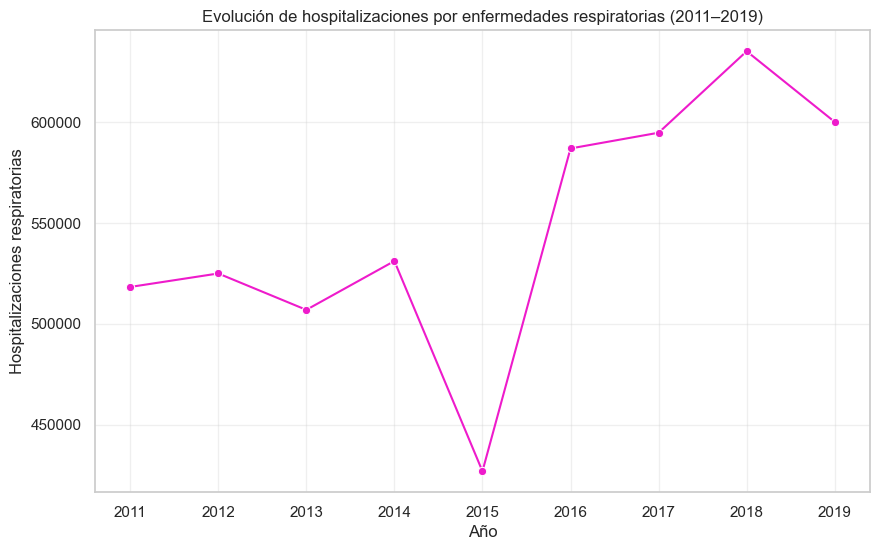

In [39]:
# hospitalizaciones respiratorias (2011-2019)

plt.figure(figsize=(10,6))
sns.lineplot(data=df_hospi,x='year',y='hospitalizations',marker='o',color="#ee1bcb")
plt.title("Evolución de hospitalizaciones por enfermedades respiratorias (2011–2019)")
plt.xlabel("Año")
plt.ylabel("Hospitalizaciones respiratorias")
plt.grid(alpha=0.3)
plt.show()

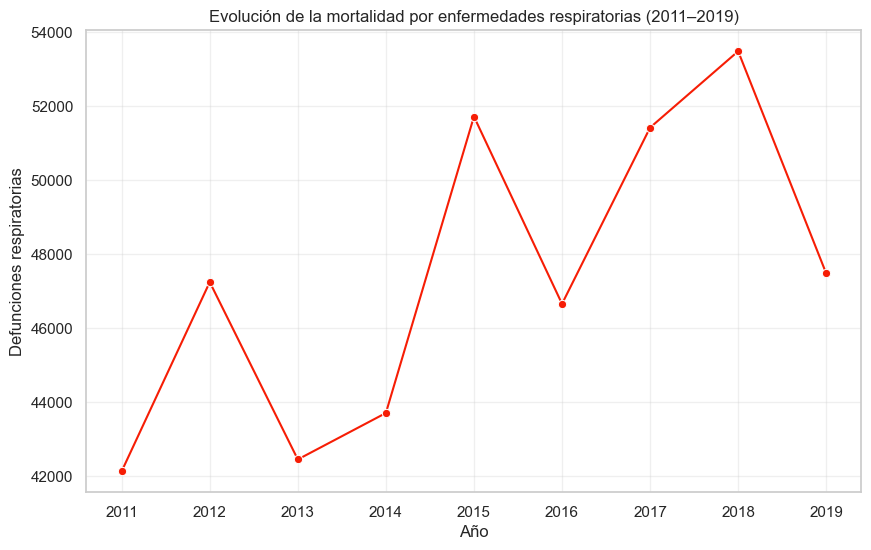

In [40]:
# mortalidad respiratoria (2011-2019)

plt.figure(figsize=(10,6))
sns.lineplot(data=df_mortality,x='year',y='deaths',marker='o',color="#f61d05")
plt.title("Evolución de la mortalidad por enfermedades respiratorias (2011–2019)")
plt.xlabel("Año")
plt.ylabel("Defunciones respiratorias")
plt.grid(alpha=0.3)
plt.show()

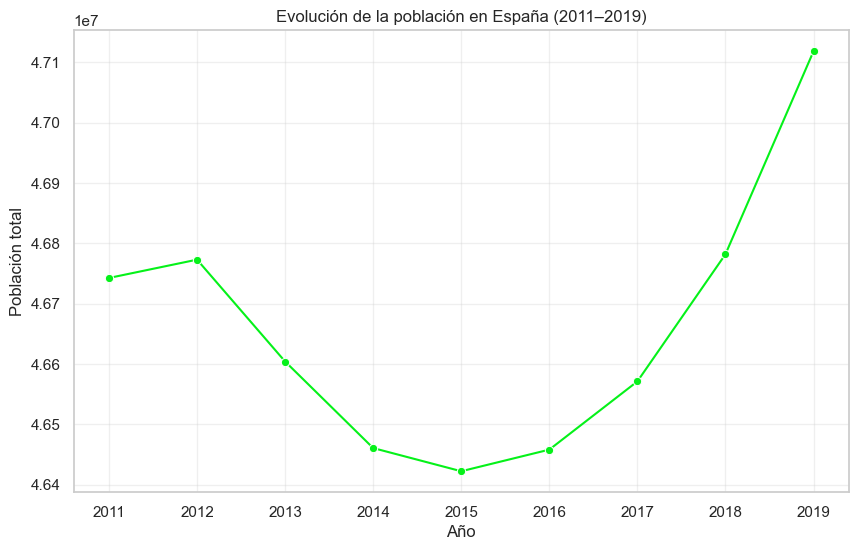

In [41]:
# población (2011-2019)

plt.figure(figsize=(10,6))
sns.lineplot(data=df_population,x='year',y='population',marker='o',color="#05f119")
plt.title("Evolución de la población en España (2011–2019)")
plt.xlabel("Año")
plt.ylabel("Población total")
plt.grid(alpha=0.3)
plt.show()

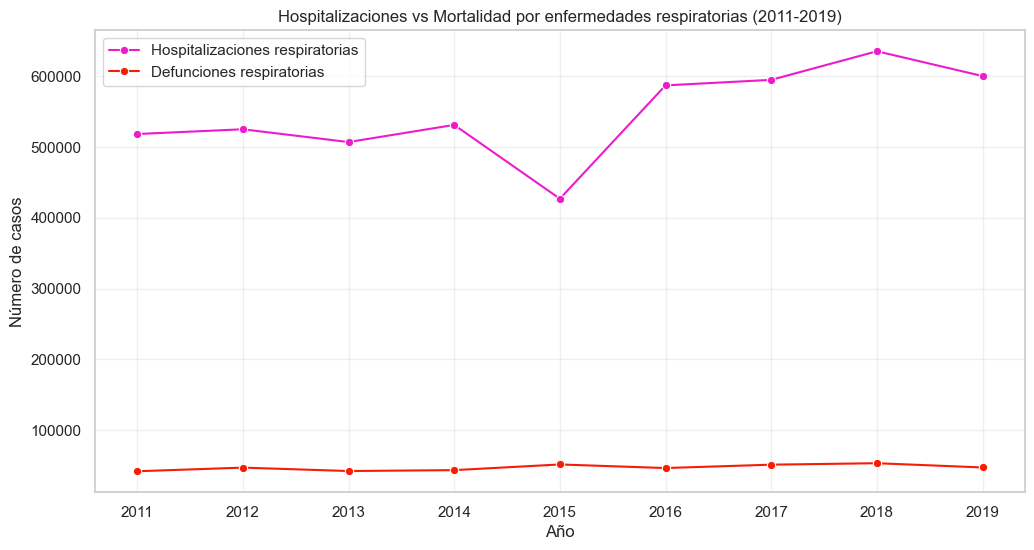

In [42]:
# comparativa hospitalizaciones respiratorias vs mortalidad respiratoria

plt.figure(figsize=(12,6))

sns.lineplot(data=df_hospi,x='year',y='hospitalizations',marker='o',label='Hospitalizaciones respiratorias',color="#ee1bcb")

sns.lineplot(data=df_mortality,x='year',y='deaths',marker='o',label='Defunciones respiratorias',color="#f61d05")

plt.title("Hospitalizaciones vs Mortalidad por enfermedades respiratorias (2011-2019)")
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

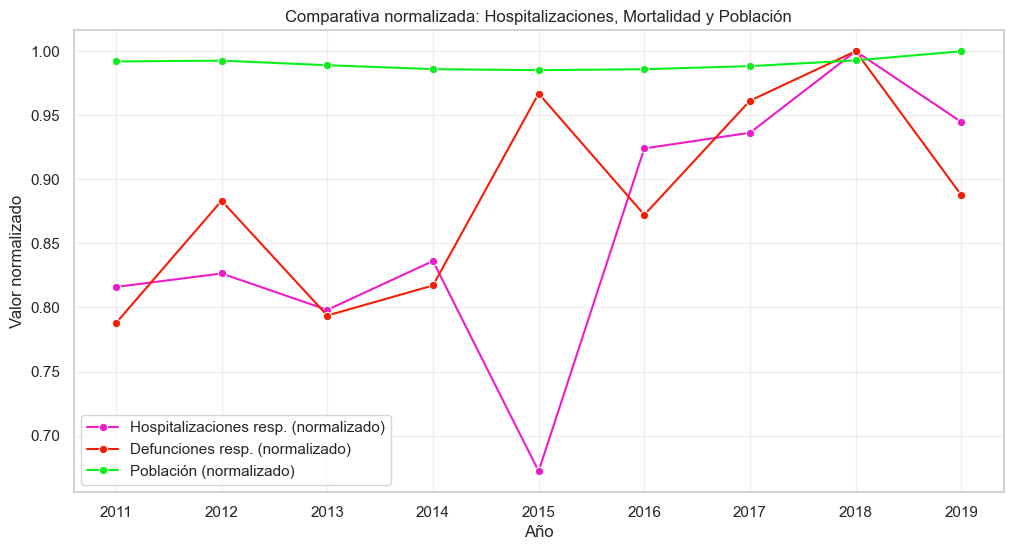

In [43]:
# comparativa de hospitalizaciones, mortalidad y población

# fusionamos los tres df
df_plot = (df_hospi.merge(df_mortality, on=['region','year']).merge(df_population, on=['region','year']))

# normalizamos para comparar tendencias
df_norm = df_plot.copy()
df_norm['hospitalizations_norm'] = df_norm['hospitalizations'] / df_norm['hospitalizations'].max()
df_norm['deaths_norm'] = df_norm['deaths'] / df_norm['deaths'].max()
df_norm['population_norm'] = df_norm['population'] / df_norm['population'].max()

plt.figure(figsize=(12,6))

sns.lineplot(data=df_norm,x='year',y='hospitalizations_norm',marker='o',label='Hospitalizaciones resp. (normalizado)',color="#ee1bcb")

sns.lineplot(data=df_norm,x='year',y='deaths_norm',marker='o',label='Defunciones resp. (normalizado)',color="#f61d05")

sns.lineplot(data=df_norm,x='year',y='population_norm',marker='o',label='Población (normalizado)',color="#05f119")

plt.title("Comparativa normalizada: Hospitalizaciones, Mortalidad y Población")
plt.xlabel("Año")
plt.ylabel("Valor normalizado")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [44]:
# voy a calcular las tasas por 100.000 habitantes para hospitalizaciones respiratorias y mortalidad respiratoria

# unimos hospitalizaciones, mortalidad y población por año
df_health = (df_hospi.merge(df_mortality, on=['region','year']).merge(df_population, on=['region','year']))
df_health

,region,year,hospitalizations,deaths,population
0,ES,2011,518276,42125,46742697
1,ES,2012,524962,47237,46773055
2,ES,2013,506929,42444,46604197
3,ES,2014,531124,43699,46460733
4,ES,2015,426914,51711,46422303
5,ES,2016,586945,46649,46458139
6,ES,2017,594741,51413,46571232
7,ES,2018,635132,53476,46782011
8,ES,2019,600088,47470,47118501


In [45]:
# calculo de tasas por 100.000 habitantes
df_health['hospitalizations_rate'] = (df_health['hospitalizations'] / df_health['population']) * 100000
df_health['mortality_rate'] = (df_health['deaths'] / df_health['population']) * 100000

df_health

,region,year,hospitalizations,deaths,population,hospitalizations_rate,mortality_rate
0,ES,2011,518276,42125,46742697,1108.784972,90.121030
1,ES,2012,524962,47237,46773055,1122.359872,100.991907
2,ES,2013,506929,42444,46604197,1087.732506,91.073343
3,ES,2014,531124,43699,46460733,1143.167500,94.055770
4,ES,2015,426914,51711,46422303,919.631238,111.392578
5,ES,2016,586945,46649,46458139,1263.384657,100.410824
6,ES,2017,594741,51413,46571232,1277.056617,110.396478
7,ES,2018,635132,53476,46782011,1357.641509,114.308895
8,ES,2019,600088,47470,47118501,1273.571925,100.745989


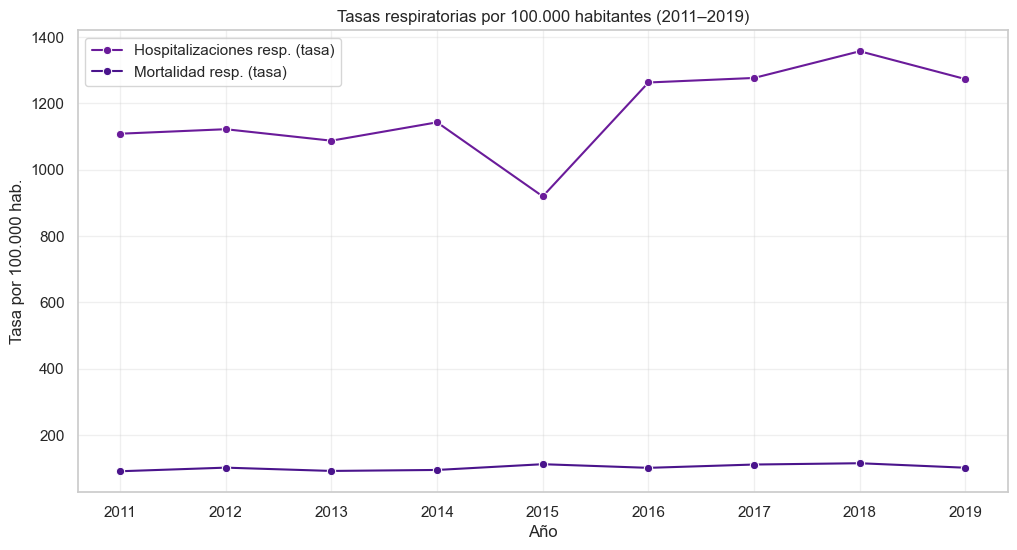

In [46]:
# comparativa de tasas (hospitalizaciones vs mortalidad)
plt.figure(figsize=(12,6))

sns.lineplot(data=df_health, x='year', y='hospitalizations_rate',
             marker='o', label='Hospitalizaciones resp. (tasa)', color='#6a1b9a')

sns.lineplot(data=df_health, x='year', y='mortality_rate',
             marker='o', label='Mortalidad resp. (tasa)', color='#4a148c')

plt.title("Tasas respiratorias por 100.000 habitantes (2011–2019)")
plt.xlabel("Año")
plt.ylabel("Tasa por 100.000 hab.")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

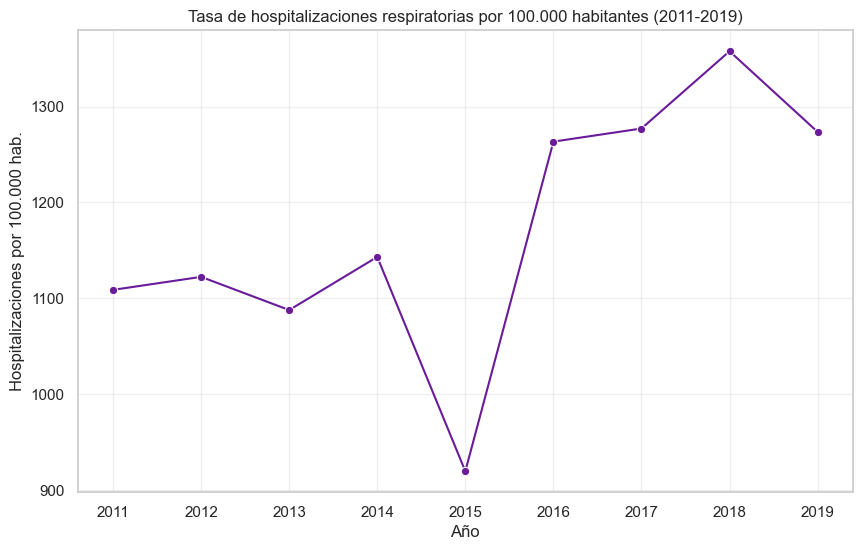

In [47]:
# gráfica de tasa de hospitalizaciones respiratorias
plt.figure(figsize=(10,6))
sns.lineplot(data=df_health,x='year',y='hospitalizations_rate',marker='o',color='#6a1b9a')
plt.title("Tasa de hospitalizaciones respiratorias por 100.000 habitantes (2011-2019)")
plt.xlabel("Año")
plt.ylabel("Hospitalizaciones por 100.000 hab.")
plt.grid(alpha=0.3)
plt.show()

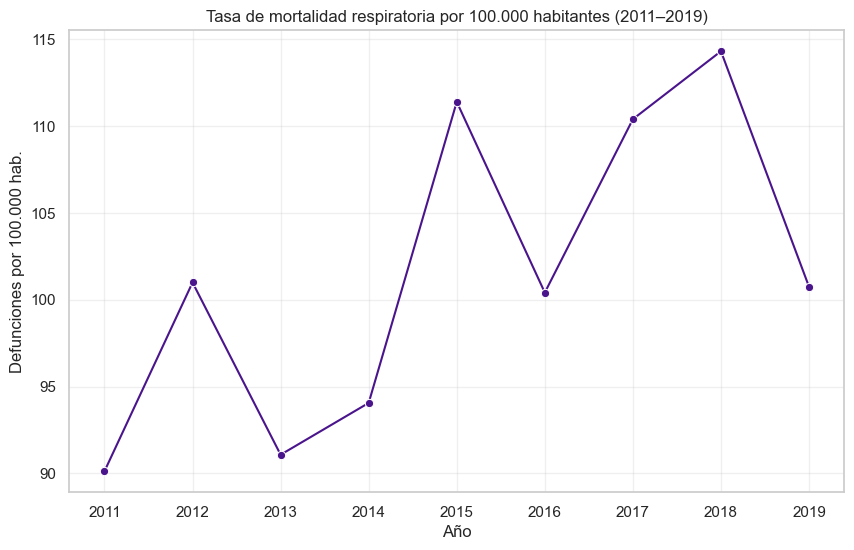

In [48]:
# gráfica de tasa de mortalidad respiratoria
plt.figure(figsize=(10,6))
sns.lineplot(data=df_health,x='year',y='mortality_rate',marker='o',color='#4a148c')
plt.title("Tasa de mortalidad respiratoria por 100.000 habitantes (2011–2019)")
plt.xlabel("Año")
plt.ylabel("Defunciones por 100.000 hab.")
plt.grid(alpha=0.3)
plt.show()

In [49]:
# porcentaje de personas hospitalizadas por enfermedades respiratorias que terminan falleciendo por causas respiratorias
df_health['fatality_pct'] = (df_health['deaths'] / df_health['hospitalizations']) * 100
df_health['fatality_pct'] = df_health['fatality_pct'].round(2)

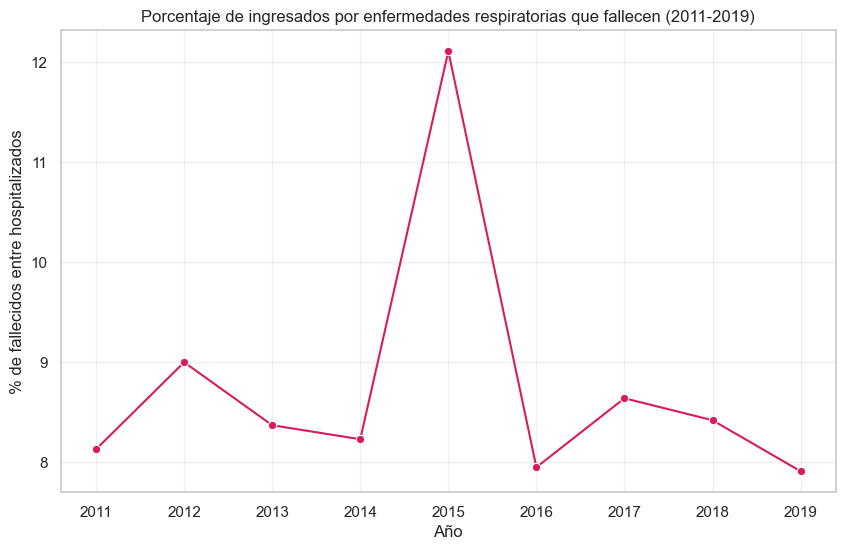

In [50]:
# la letalidad hospitalaria respiratoria suele oscilar entre 7% y 10%
# gráfica del porcentaje de letalidad respiratoria

plt.figure(figsize=(10,6))
sns.lineplot(data=df_health,x='year',y='fatality_pct',marker='o',color='#d81b60')
plt.title("Porcentaje de ingresados por enfermedades respiratorias que fallecen (2011-2019)")
plt.xlabel("Año")
plt.ylabel("% de fallecidos entre hospitalizados")
plt.grid(alpha=0.3)
plt.show()

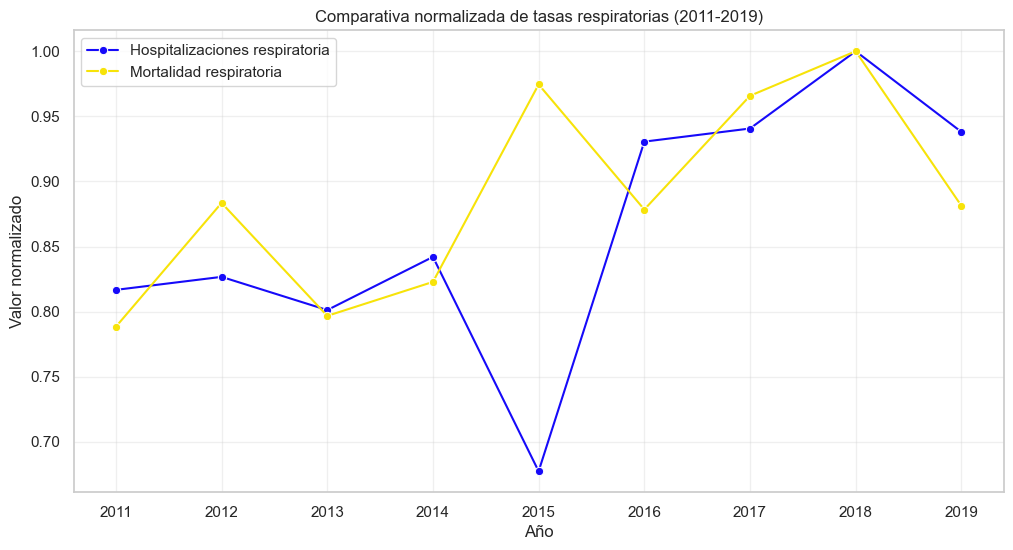

In [51]:
# comparativa normalizada de tasas (tendencias relativas), muy útil para ver si ambas curvas suben/bajan a la vez

df_norm_rates = df_health.copy()
df_norm_rates['hospitalizations_rate_norm'] = df_norm_rates['hospitalizations_rate'] / df_norm_rates['hospitalizations_rate'].max()
df_norm_rates['mortality_rate_norm'] = df_norm_rates['mortality_rate'] / df_norm_rates['mortality_rate'].max()

plt.figure(figsize=(12,6))

sns.lineplot(data=df_norm_rates,x='year',y='hospitalizations_rate_norm',marker='o',label='Hospitalizaciones respiratoria',color="#160af9")

sns.lineplot(data=df_norm_rates,x='year',y='mortality_rate_norm',marker='o',label='Mortalidad respiratoria',color="#f7e309")

plt.title("Comparativa normalizada de tasas respiratorias (2011-2019)")
plt.xlabel("Año")
plt.ylabel("Valor normalizado")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [52]:
# antes hice indicadores de salud respiratoria (hospitalizaciones, mortalidad, tasas, letalidad…)

# ahora haré relación salud con  contaminación(merge, comparativas, correlaciones, conclusión)

## H1 Relación entre contaminación atmosférica y salud respiratoria

En esta sección analizamos si existe relación entre los indicadores de salud respiratoria
(hospitalizaciones, mortalidad, tasas y letalidad) y los niveles de contaminación atmosférica.

El objetivo es evaluar si los años con mayor concentración de contaminantes presentan
también un mayor impacto en la salud respiratoria, tal como plantea la hipótesis H1.

In [53]:
# agregación anual de contaminantes, agrupamos por año para obtener la concentración media anual de cada contaminante


# limpiar valores negativos
df_pollutants_stations["Value"] = df_pollutants_stations["Value"].mask(
    df_pollutants_stations["Value"] < 0,
    np.nan
)

# extraer el año REAL desde la columna date
df_pollutants_stations["date"] = pd.to_datetime(df_pollutants_stations["date"])
df_pollutants_stations["year"] = df_pollutants_stations["date"].dt.year

# agregación anual de contaminantes
pollutants_yearly = (df_pollutants_stations.pivot_table(index="year",columns="pollutant",values="Value",aggfunc="mean").reset_index())

pollutants_yearly

pollutant,year,C6H6,CO,NO2,O3,PM10,PM25,SO2
0,2011,NaN,NaN,NaN,57.605000,NaN,11.795948,NaN
1,2012,NaN,NaN,NaN,58.131193,NaN,10.691616,NaN
2,2013,0.687336,0.315632,19.617679,61.795513,36.046411,8.414929,11.961480
3,2014,0.675224,0.282245,17.821290,59.079797,19.026906,8.440634,4.602034
4,2015,0.745848,0.304125,19.510600,58.367238,20.601320,9.642178,4.690040
5,2016,0.639614,0.308748,18.082504,57.914092,18.724881,8.522382,4.259838
6,2017,0.605762,0.312260,19.153453,56.394518,20.996774,9.665476,4.409768
7,2018,0.558097,0.302889,16.768758,58.206911,18.811840,9.112622,4.032753
8,2019,0.540079,0.318126,16.168204,58.722936,19.164135,9.131447,4.001003


In [54]:
# unimos salud + contaminación
df_health_pollut = df_health.merge(pollutants_yearly,on="year",how="left")

df_health_pollut

,region,year,hospitalizations,deaths,population,hospitalizations_rate,mortality_rate,fatality_pct,C6H6,CO,NO2,O3,PM10,PM25,SO2
0,ES,2011,518276,42125,46742697,1108.784972,90.121030,8.13,NaN,NaN,NaN,57.605000,NaN,11.795948,NaN
1,ES,2012,524962,47237,46773055,1122.359872,100.991907,9.00,NaN,NaN,NaN,58.131193,NaN,10.691616,NaN
2,ES,2013,506929,42444,46604197,1087.732506,91.073343,8.37,0.687336,0.315632,19.617679,61.795513,36.046411,8.414929,11.961480
3,ES,2014,531124,43699,46460733,1143.167500,94.055770,8.23,0.675224,0.282245,17.821290,59.079797,19.026906,8.440634,4.602034
4,ES,2015,426914,51711,46422303,919.631238,111.392578,12.11,0.745848,0.304125,19.510600,58.367238,20.601320,9.642178,4.690040
5,ES,2016,586945,46649,46458139,1263.384657,100.410824,7.95,0.639614,0.308748,18.082504,57.914092,18.724881,8.522382,4.259838
6,ES,2017,594741,51413,46571232,1277.056617,110.396478,8.64,0.605762,0.312260,19.153453,56.394518,20.996774,9.665476,4.409768
7,ES,2018,635132,53476,46782011,1357.641509,114.308895,8.42,0.558097,0.302889,16.768758,58.206911,18.811840,9.112622,4.032753
8,ES,2019,600088,47470,47118501,1273.571925,100.745989,7.91,0.540079,0.318126,16.168204,58.722936,19.164135,9.131447,4.001003


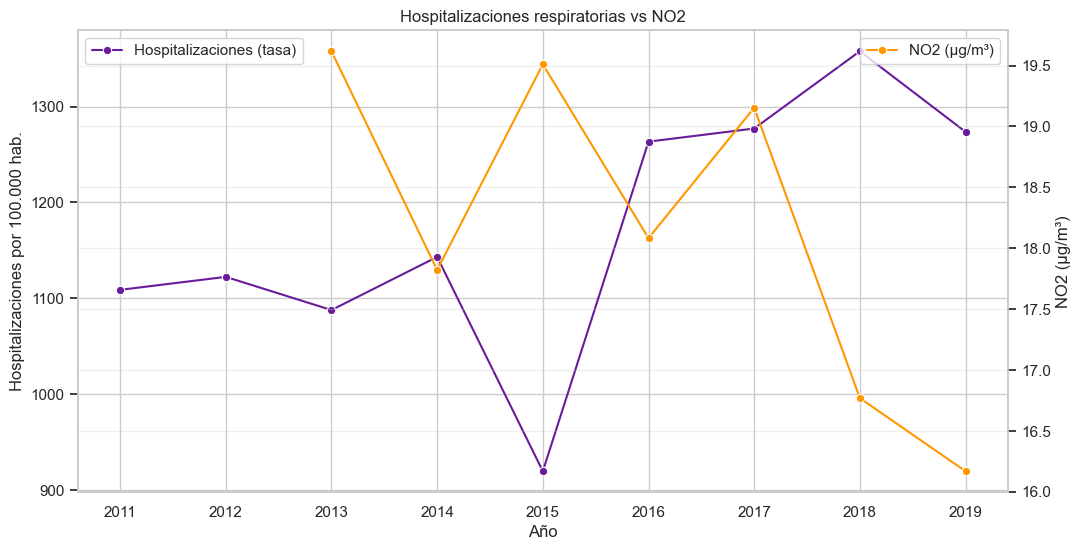

In [100]:
# gráficas comparadas: salud vs contaminantes

#  hospitalizaciones vs NO2
fig, ax1 = plt.subplots(figsize=(12,6))

sns.lineplot(data=df_health_pollut, x="year", y="hospitalizations_rate",marker="o", color="#6a1b9a", label="Hospitalizaciones (tasa)", ax=ax1)

ax2 = ax1.twinx()
sns.lineplot(data=df_health_pollut, x="year", y="NO2",marker="o", color="#ff9800", label="NO2 (µg/m³)", ax=ax2)

ax1.set_title("Hospitalizaciones respiratorias vs NO2")
ax1.set_xlabel("Año")
ax1.set_ylabel("Hospitalizaciones por 100.000 hab.")
ax2.set_ylabel("NO2 (µg/m³)")

plt.grid(alpha=0.3)
plt.show()

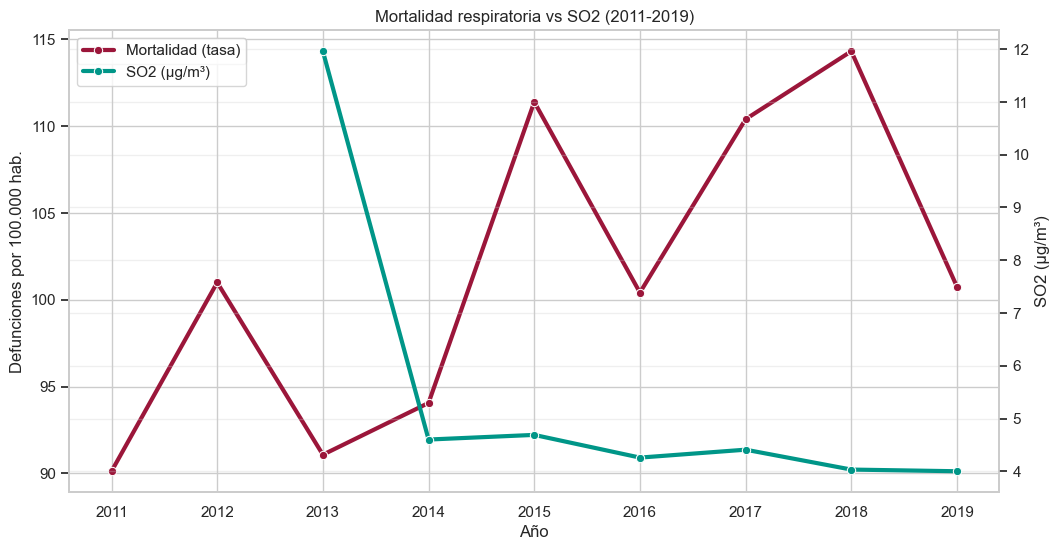

In [117]:
# mortalidad vs PM10
fig, ax1 = plt.subplots(figsize=(12,6))

sns.lineplot(data=df_health_pollut, x="year", y="mortality_rate",marker="o", color="#9b163a", linewidth=3, label="Mortalidad (tasa)", ax=ax1)

ax2 = ax1.twinx()
sns.lineplot(data=df_health_pollut, x="year", y="SO2",marker="o", color="#009688",linewidth=3, label="SO2 (µg/m³)", ax=ax2)

ax1.set_title("Mortalidad respiratoria vs SO2 (2011-2019)")
ax1.set_xlabel("Año")
ax1.set_ylabel("Defunciones por 100.000 hab.")
ax2.set_ylabel("SO2 (µg/m³)")

plt.grid(alpha=0.3)


line1 = ax1.lines[0]
line2 = ax2.lines[0] 

labels = ["Mortalidad (tasa)", "SO2 (µg/m³)"]

plt.legend(handles=[line1, line2],
    labels=["Mortalidad (tasa)", "SO2 (µg/m³)"],
    loc="upper left")

plt.show()

In [59]:
# correlaciones salud <-> contaminación

corr = df_health_pollut[["hospitalizations_rate", "mortality_rate", "fatality_pct","NO2", "PM10", "PM25", "O3"]].corr()

corr

,hospitalizations_rate,mortality_rate,fatality_pct,NO2,PM10,PM25,O3
hospitalizations_rate,1.000000,0.260341,-0.722384,-0.674909,-0.357795,-0.247635,-0.316119
mortality_rate,0.260341,1.000000,0.475744,-0.091954,-0.532233,-0.102245,-0.495514
fatality_pct,-0.722384,0.475744,1.000000,0.520201,-0.040979,0.128195,-0.060834
NO2,-0.674909,-0.091954,0.520201,1.000000,0.566566,0.109868,0.177164
PM10,-0.357795,-0.532233,-0.040979,0.566566,1.000000,-0.355650,0.797175
PM25,-0.247635,-0.102245,0.128195,0.109868,-0.355650,1.000000,-0.487156
O3,-0.316119,-0.495514,-0.060834,0.177164,0.797175,-0.487156,1.000000


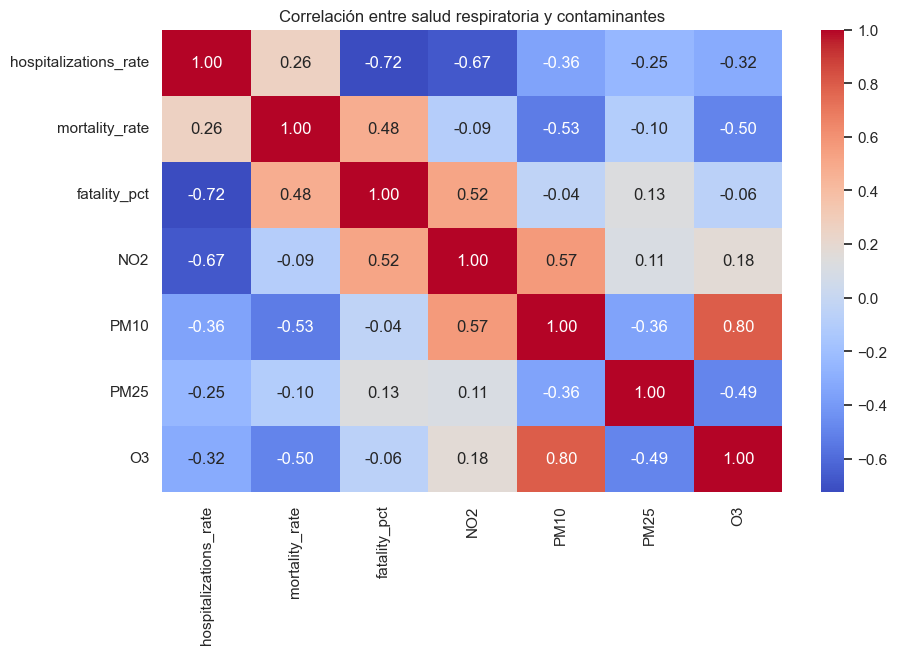

In [60]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre salud respiratoria y contaminantes")
plt.show()

# rojo = correlación positiva alta (cercana a +1)
# azul = correlación negativa alta (cercana a –1)
# blanco = correlación débil o nula (cercana a 0)

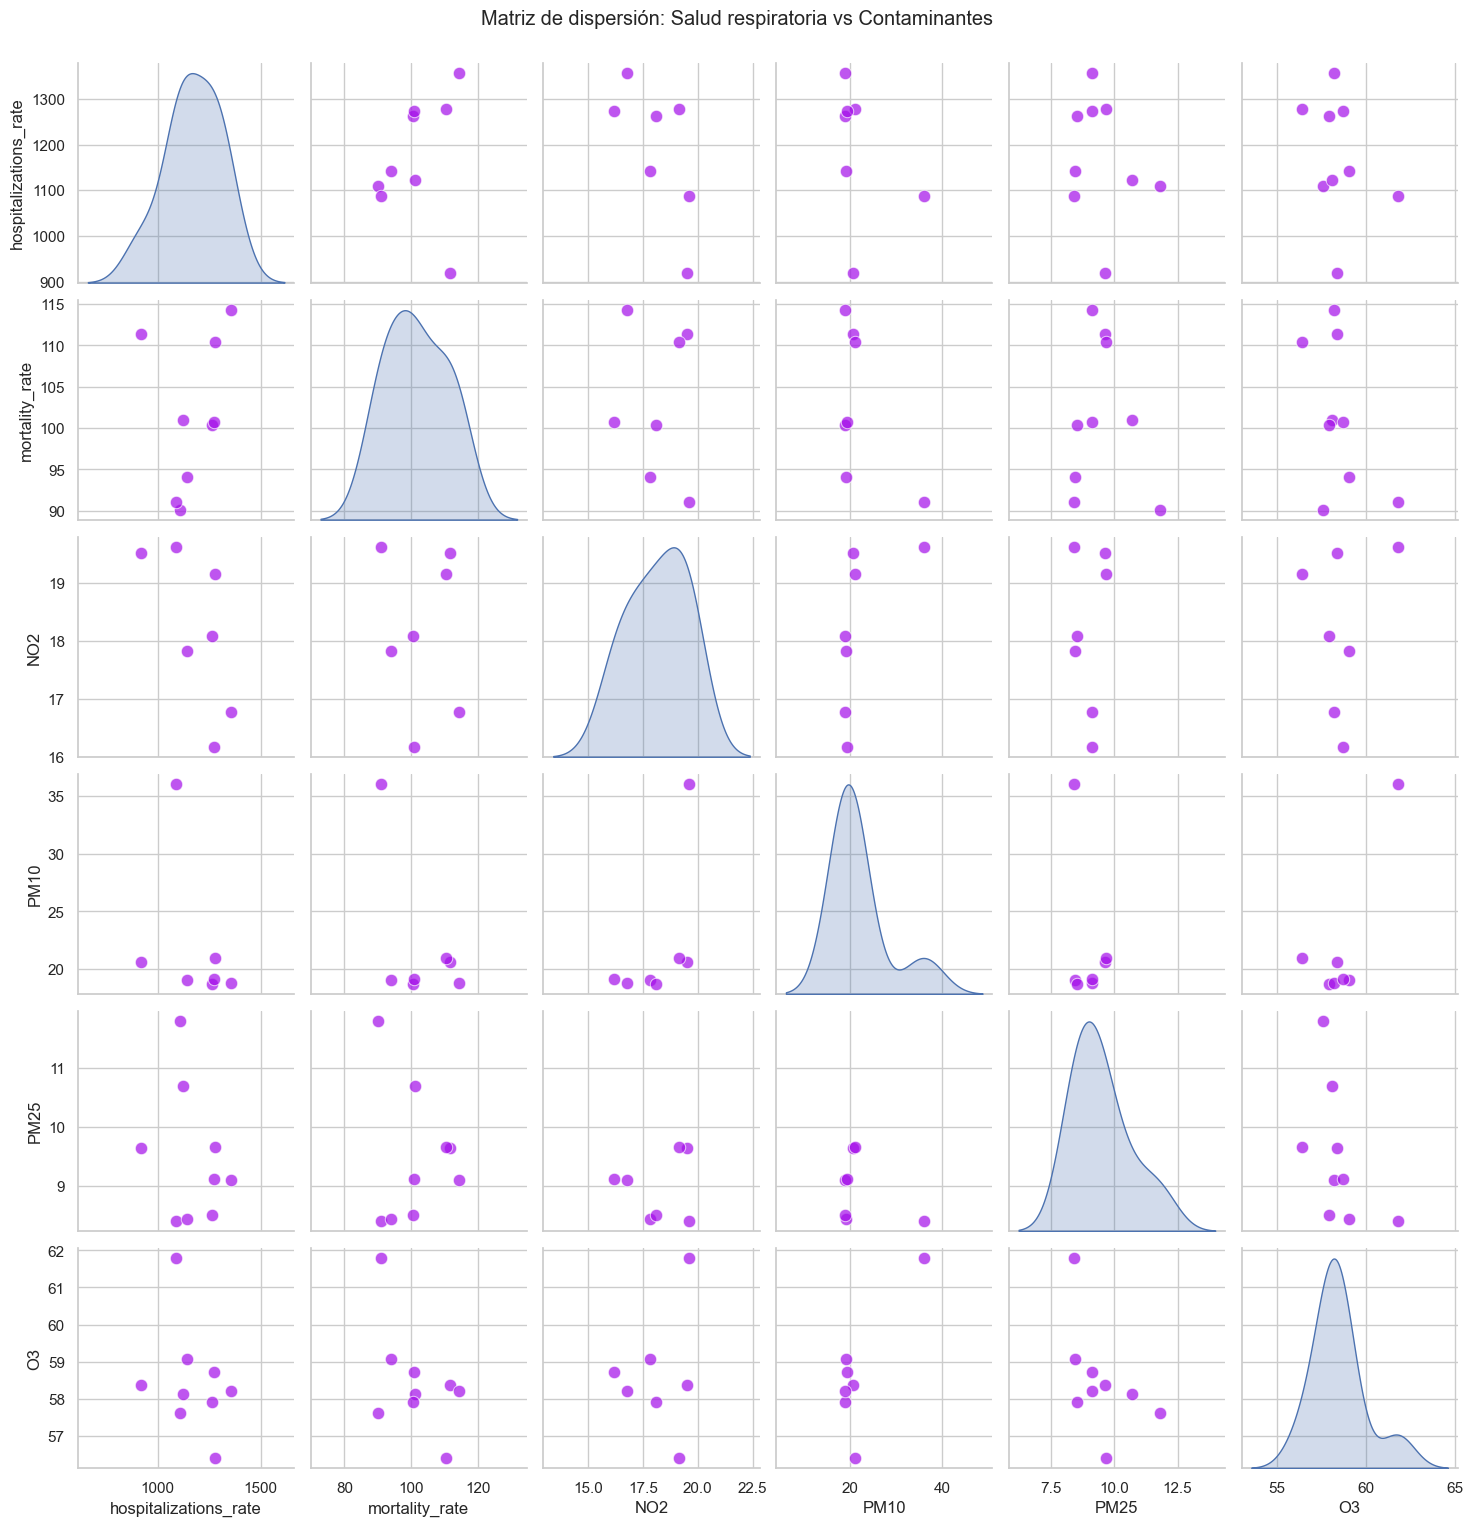

In [63]:
# gráfico multivariante: scatter matrix (pairplot)


vars_health_pollut = ["hospitalizations_rate", "mortality_rate", "NO2", "PM10", "PM25", "O3"]

sns.pairplot(df_health_pollut[vars_health_pollut], diag_kind="kde",
             plot_kws={"s": 80, "alpha": 0.7, "color": "#a30de9"})
plt.suptitle("Matriz de dispersión: Salud respiratoria vs Contaminantes", y=1.02)
plt.show()

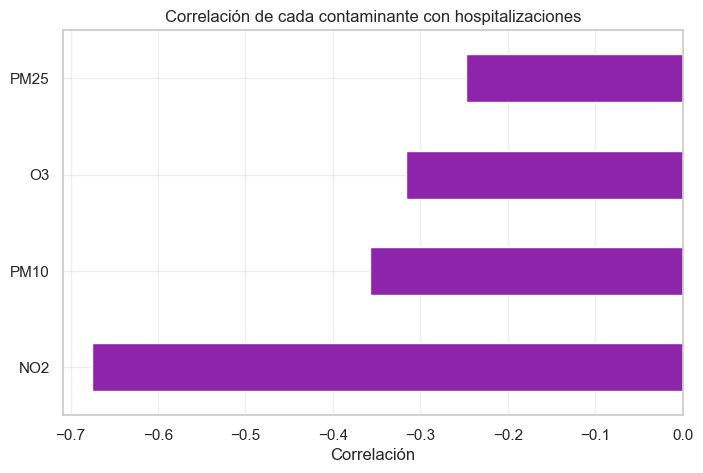

In [64]:
# correlaciones dirigidas: barras para hospitalizaciones

corr_hospi = df_health_pollut[["hospitalizations_rate", "NO2", "PM10", "PM25", "O3"]].corr()["hospitalizations_rate"]
corr_hospi = corr_hospi.drop("hospitalizations_rate").sort_values()

plt.figure(figsize=(8,5))
corr_hospi.plot(kind="barh", color="#8e24aa")
plt.title("Correlación de cada contaminante con hospitalizaciones")
plt.xlabel("Correlación")
plt.grid(alpha=0.3)
plt.show()


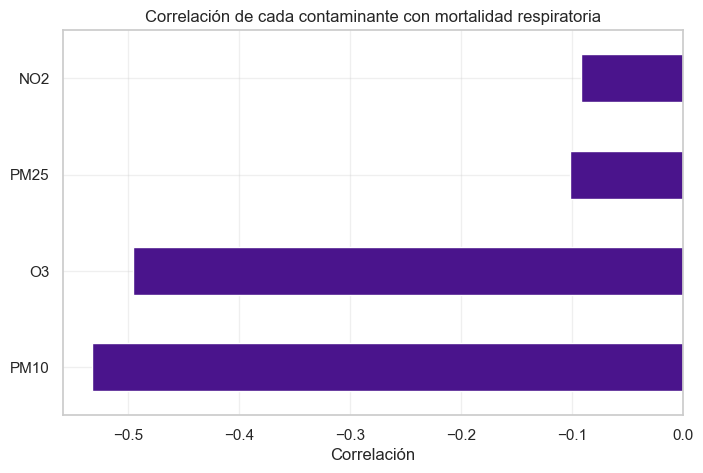

In [65]:
# correlaciones dirigidas: barras para mortalidad


corr_mort = df_health_pollut[["mortality_rate", "NO2", "PM10", "PM25", "O3"]].corr()["mortality_rate"]
corr_mort = corr_mort.drop("mortality_rate").sort_values()

plt.figure(figsize=(8,5))
corr_mort.plot(kind="barh", color="#4a148c")
plt.title("Correlación de cada contaminante con mortalidad respiratoria")
plt.xlabel("Correlación")
plt.grid(alpha=0.3)
plt.show()


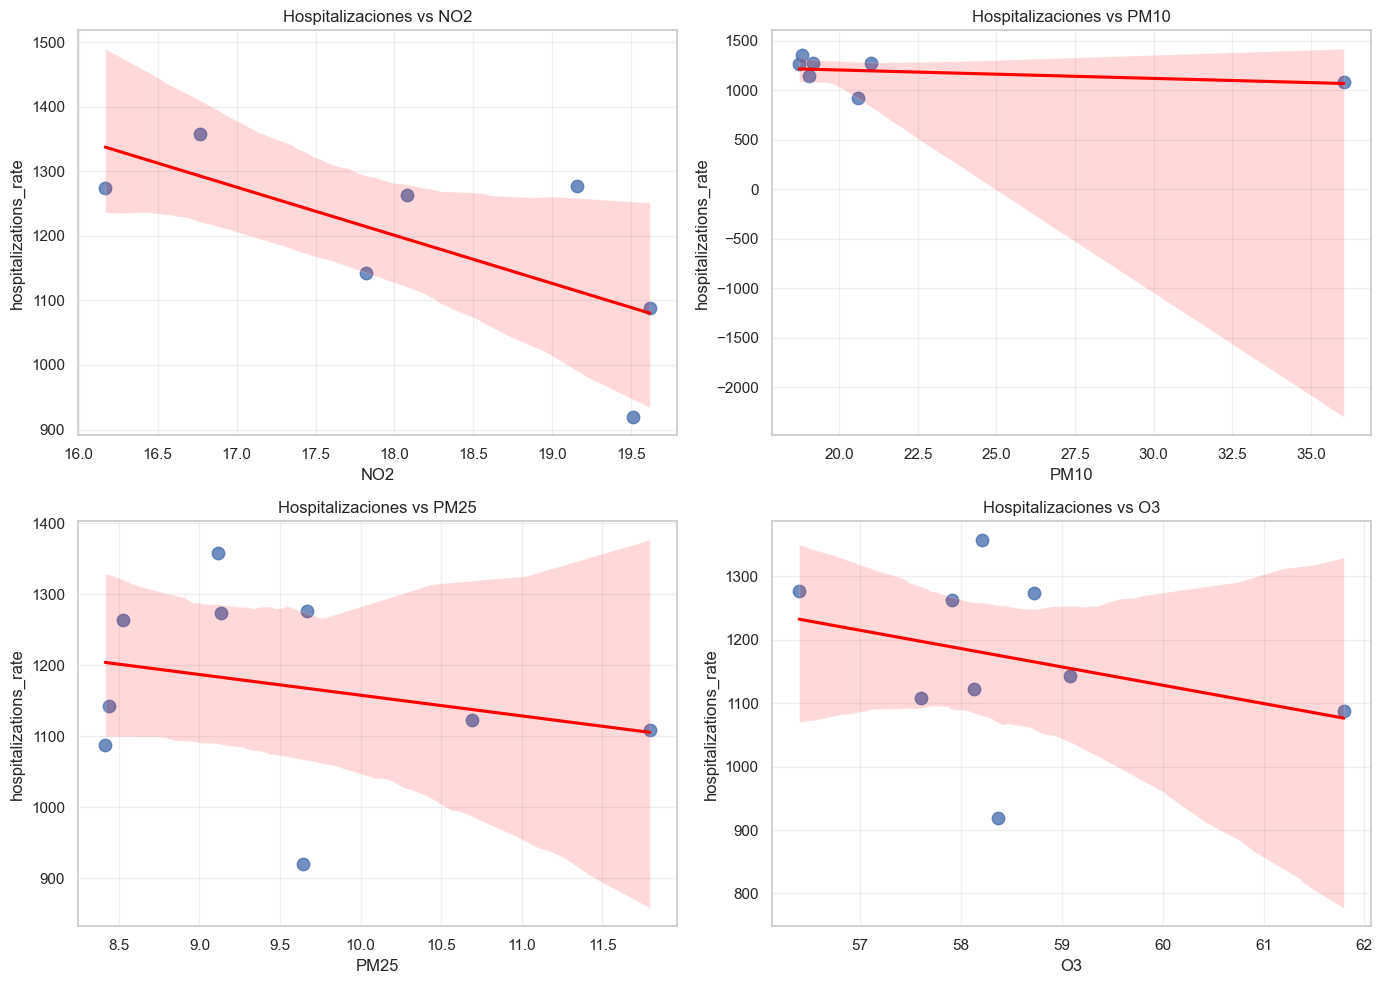

In [66]:
# facetgrid: regresiones para cada contaminante

pollutants = ["NO2", "PM10", "PM25", "O3"]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

for ax, pol in zip(axes.flatten(), pollutants):
    sns.regplot(data=df_health_pollut, x=pol, y="hospitalizations_rate",
                ax=ax, scatter_kws={"s":80}, line_kws={"color":"red"})
    ax.set_title(f"Hospitalizaciones vs {pol}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


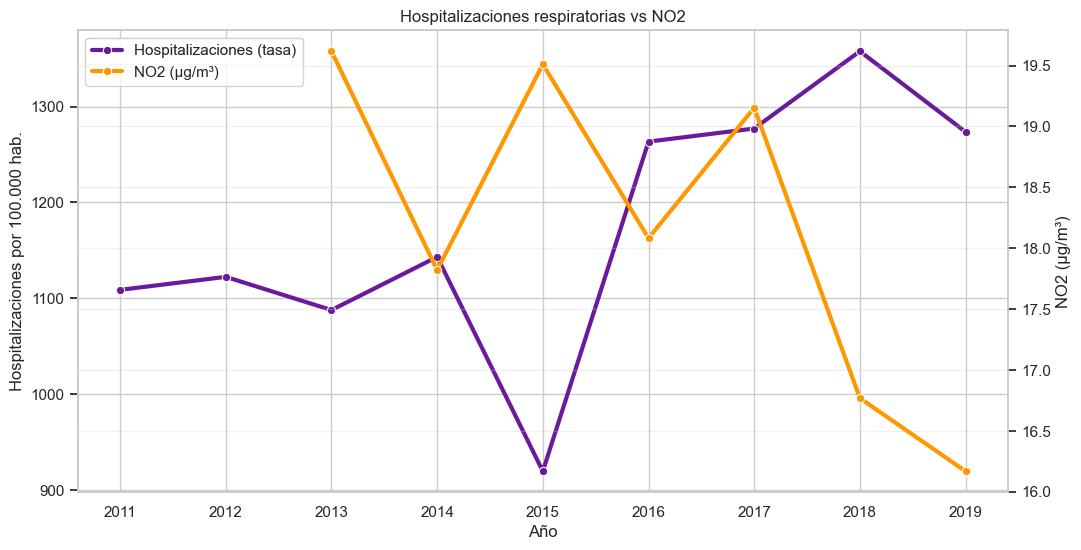

In [67]:
#  hospitalizaciones vs NO2
fig, ax1 = plt.subplots(figsize=(12,6))

sns.lineplot(data=df_health_pollut, x="year", y="hospitalizations_rate",marker="o", color="#6a1b9a",linewidth=3, label="Hospitalizaciones (tasa)", ax=ax1)

ax2 = ax1.twinx()
sns.lineplot(data=df_health_pollut, x="year", y="NO2",marker="o", color="#ff9800",linewidth=3, label="NO2 (µg/m³)", ax=ax2)

ax1.set_title("Hospitalizaciones respiratorias vs NO2")
ax1.set_xlabel("Año")
ax1.set_ylabel("Hospitalizaciones por 100.000 hab.")
ax2.set_ylabel("NO2 (µg/m³)")

plt.grid(alpha=0.3)


line1 = ax1.lines[0]
line2 = ax2.lines[0] 

labels = ["Hospitalizaciones (tasa)", "NO2 (µg/m³)"]

plt.legend(handles=[line1, line2],
    labels=["Hospitalizaciones (tasa)", "NO2 (µg/m³)"],
    loc="upper left")

plt.show()


In [ ]:
'''
Hospitalizaciones respiratorias vs NO₂
(gráfico de líneas con dos ejes)

En este gráfico comparo cómo cambian las hospitalizaciones respiratorias y los niveles de NO₂ a lo largo de los años.
Si la contaminación afectara claramente a la salud, las dos líneas deberían subir y bajar más o menos a la vez.
Pero aquí se ve que cada una va por su lado: hay años con más NO₂ y menos hospitalizaciones, y años con menos NO₂ y más hospitalizaciones.
Esto significa que no hay una relación clara entre NO₂ y hospitalizaciones en estos datos

Las dos líneas no se parecen en nada → no se mueven juntas → no hay relación
'''

'\nHospitalizaciones respiratorias vs NO₂\n(gráfico de líneas con dos ejes)\n\nExplicación sencilla para decir en clase\n“En este gráfico comparo cómo cambian las hospitalizaciones respiratorias y los niveles de NO₂ a lo largo de los años.\nSi la contaminación afectara claramente a la salud, las dos líneas deberían subir y bajar más o menos a la vez.\nPero aquí se ve que cada una va por su lado: hay años con más NO₂ y menos hospitalizaciones, y años con menos NO₂ y más hospitalizaciones.\nEsto significa que no hay una relación clara entre NO₂ y hospitalizaciones en estos datos.”\n\nIdea clave\n“Las dos líneas no se parecen en nada → no se mueven juntas → no hay relación.”\n\n'

C:\Users\titea\AppData\Local\Temp\ipykernel_20036\196730328.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


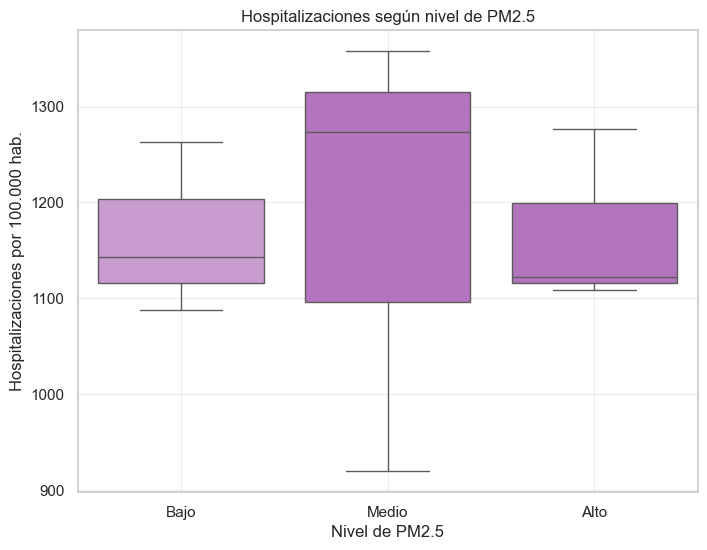

In [ ]:
# crear categorías de PM2.5
df_health_pollut["PM25_cat"] = pd.qcut(df_health_pollut["PM25"], q=3, labels=["Bajo","Medio","Alto"])

plt.figure(figsize=(8,6))
sns.boxplot(
    data=df_health_pollut,
    x="PM25_cat",
    y="hospitalizations_rate",
    palette=["#ce93d8","#ba68c8","#ba68c8"]
)
plt.title("Hospitalizaciones según nivel de PM2.5")
plt.xlabel("Nivel de PM2.5")
plt.ylabel("Hospitalizaciones por 100.000 hab.")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
'''
Interpretación del boxplot
Este gráfico divide los años en tres grupos según cuánto PM2.5 había:
bajo, medio y alto.

Cada caja representa cuántas hospitalizaciones respiratorias hubo en esos años.

Lo importante es lo siguiente:

1. Las tres cajas son muy parecidas
Si la contaminación afectara claramente a la salud, esperaríamos que:
    la caja de PM2.5 alto estuviera claramente más arriba (es decir, más hospitalizaciones)

Pero no pasa eso.
Las cajas están casi al mismo nivel.

2. El grupo “medio” incluso tiene más hospitalizaciones que el “alto”
Esto va justo en contra de la idea de que “más contaminación = más hospitalizaciones”.

3. La variación dentro de cada grupo es mayor que la diferencia entre grupos
Es decir:
    Dentro de cada nivel de PM2.5, los valores suben y bajan mucho.

    Pero entre niveles, apenas cambia nada.

Esto significa que el PM2.5 no explica por qué suben o bajan las hospitalizaciones.

Si el PM2.5 tuviera un impacto claro en la salud, veríamos más hospitalizaciones en el grupo de contaminación alta. Pero las tres cajas están casi igual, así que no hay relación evidente.
'''


'\nBoxplot: Hospitalizaciones según nivel de PM2.5\n(el que tú quieres usar)\n\nExplicación sencilla para decir en clase\n“Este gráfico divide los años en tres grupos según cuánto PM2.5 había: bajo, medio y alto.\nSi el PM2.5 afectara claramente a la salud, esperaríamos que el grupo de contaminación alta tuviera muchas más hospitalizaciones.\nPero las tres cajas están casi al mismo nivel.\nIncluso el grupo ‘medio’ tiene más hospitalizaciones que el ‘alto’.\nEsto demuestra que el nivel de PM2.5 no explica las hospitalizaciones en estos datos.”\n\nIdea clave\n“Si hubiera relación, la caja de ‘alto PM2.5’ estaría claramente más arriba. Pero no lo está.”\n'

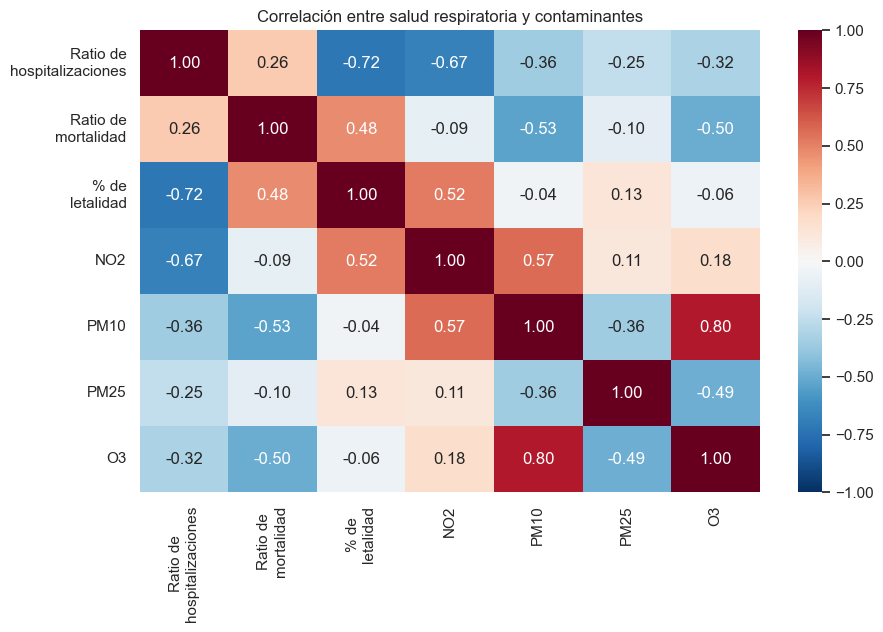

In [ ]:
# Renombrar columnas del dataframe de correlaciones
corr_renombrada = corr.rename(index={
    "hospitalizations_rate": "Ratio de\nhospitalizaciones",
    "mortality_rate": "Ratio de\nmortalidad",
    "fatality_pct": "% de\nletalidad"
}).rename(columns={
    "hospitalizations_rate": "Ratio de\nhospitalizaciones",
    "mortality_rate": "Ratio de\nmortalidad",
    "fatality_pct": "% de\nletalidad"
})

plt.figure(figsize=(10,6))
sns.heatmap(
    corr_renombrada,
    annot=True,
    cmap="RdBu_r",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0
)
plt.title("Correlación entre salud respiratoria y contaminantes")
plt.show()



# rojo = correlación positiva alta (cercana a +1)
# azul = correlación negativa alta (cercana a –1)
# blanco = correlación débil o nula (cercana a 0)

In [ ]:
'''
Heatmap de correlaciones
(el gráfico más importante para justificar la conclusión)

Este gráfico muestra cómo se relacionan las hospitalizaciones y la mortalidad con cada contaminante
Si la contaminación aumentara la salud respiratoria, aquí veríamos números positivos y colores rojos
Pero lo que aparece son correlaciones negativas o muy débiles
Eso significa que no hay una relación lineal clara entre contaminación y salud respiratoria en estos datos

Si la hipótesis fuera cierta, veríamos colores rojos. Pero casi todo es azul → no hay relación

Fatality_pct = porcentaje de letalidad hospitalaria. De todas las hospitalizaciones respiratorias en un año, qué porcentaje terminó en fallecimiento
    - la gravedad de los casos respiratorios
    - la evolución de la letalidad a lo largo del tiempo

'''

'\nHeatmap de correlaciones\n(el gráfico más importante para justificar la conclusión)\n\nExplicación sencilla para decir en clase\n“Este gráfico muestra cómo se relacionan las hospitalizaciones y la mortalidad con cada contaminante.\nSi la contaminación aumentara la salud respiratoria, aquí veríamos números positivos y colores rojos.\nPero lo que aparece son correlaciones negativas o muy débiles.\nEso significa que no hay una relación lineal clara entre contaminación y salud respiratoria en estos datos.”\n\nIdea clave\n“Si la hipótesis fuera cierta, veríamos colores rojos. Pero casi todo es azul → no hay relación.”\n\nFatality_pct = porcentaje de letalidad hospitalaria. De todas las hospitalizaciones respiratorias en un año, qué porcentaje terminó en fallecimiento.\n    - la gravedad de los casos respiratorios\n    - la evolución de la letalidad a lo largo del tiempo\n\n'

In [ ]:
'''
Mis datos están agregados, es decir, son promedios anuales de toda España. Eso hace que
se pierda mucha información importante: los picos de contaminación, las diferencias entre
ciudades y los efectos a corto plazo. Por eso, aunque la contaminación sí afecta a la salud,
en estos datos tan resumidos no aparece la relación.”

'''

'\nMis datos están agregados, es decir, son promedios anuales de toda España. Eso hace que\nse pierda mucha información importante: los picos de contaminación, las diferencias entre\nciudades y los efectos a corto plazo. Por eso, aunque la contaminación sí afecta a la salud,\nen estos datos tan resumidos no aparece la relación.”\n\n'

In [82]:
# Conclusión de H1
'''
¿La contaminación atmosférica aumenta el impacto en la salud respiratoria?

Con los datos agregados anuales para toda España entre 2011 y 2019, no se observa una relación clara, consistente ni positiva entre los niveles medios de contaminación y los indicadores de salud respiratoria (hospitalizaciones, mortalidad y letalidad).

    -Los análisis gráficos y estadísticos muestran que:

    -Las correlaciones entre contaminantes y salud son débiles o moderadas, y en todos los casos negativas.

    -Las series temporales de contaminación y salud no evolucionan de forma paralela.

    -Los scatterplots y las regresiones lineales muestran pendientes planas o negativas, sin patrones ascendentes.

    -La matriz de dispersión confirma que no existe una relación lineal visible entre los contaminantes y los indicadores de salud.

Por tanto, H1 no puede considerarse confirmada con este nivel de agregación.

Esto no contradice la evidencia epidemiológica existente, sino que indica que:

Los promedios anuales nacionales diluyen completamente la señal real.

La relación contaminación-salud suele detectarse en:

    datos diarios o mensuales,

    análisis por ciudad o región,

    modelos con rezagos temporales,

    episodios de contaminación,

    grupos vulnerables.

Para contrastar H1 de forma más robusta sería necesario un análisis más granular.
'''

'\n¿La contaminación atmosférica aumenta el impacto en la salud respiratoria?\n\nCon los datos agregados anuales para toda España entre 2011 y 2019, no se observa una relación clara, consistente ni positiva entre los niveles medios de contaminación y los indicadores de salud respiratoria (hospitalizaciones, mortalidad y letalidad).\n\n    -Los análisis gráficos y estadísticos muestran que:\n\n    -Las correlaciones entre contaminantes y salud son débiles o moderadas, y en todos los casos negativas.\n\n    -Las series temporales de contaminación y salud no evolucionan de forma paralela.\n\n    -Los scatterplots y las regresiones lineales muestran pendientes planas o negativas, sin patrones ascendentes.\n\n    -La matriz de dispersión confirma que no existe una relación lineal visible entre los contaminantes y los indicadores de salud.\n\nPor tanto, H1 no puede considerarse confirmada con este nivel de agregación.\n\nEsto no contradice la evidencia epidemiológica existente, sino que indi

## HIPÓTESIS 2
Las zonas costeras presentan menor contaminación que las zonas de interior
La hipótesis plantea que:
- Las zonas costeras → mejor dispersión atmosférica → menores niveles de contaminantes
- Las zonas de interior → menor ventilación → mayores concentraciones
Para contrastarla, necesitamos:
- Clasificar cada estación como “costa” o “interior”
- Calcular la media anual de contaminantes por tipo de zona
- Comparar ambas zonas
- Visualizar la diferencia


In [87]:
'''
OBJETIVO DE H2
“Las zonas costeras presentan menor contaminación que las zonas de interior.”

Para comprobarlo necesitas:

Clasificar estaciones → costa / interior

Calcular medias por zona

Comparar

Visualizar

Vamos a hacerlo.
'''

'\nOBJETIVO DE H2\n“Las zonas costeras presentan menor contaminación que las zonas de interior.”\n\nPara comprobarlo necesitas:\n\nClasificar estaciones → costa / interior\n\nCalcular medias por zona\n\nComparar\n\nVisualizar\n\nVamos a hacerlo.\n'

In [88]:
# Clasificar estaciones -> costa / interior

municipios = df_pollutants_stations["Municipality"].unique()
municipios


<ArrowStringArray>
[                'BURGOS',               'ALCORCÓN',      'TORREJÓN DE ARDOZ',
       'ALICANTE/ALACANT',               'BENIDORM',                   'ELDA',
                'BUNYOLA',                'CÁCERES',              'PLASENCIA',
            'ALCORA (L')',
 ...
                  'PONTS', 'VILLAMURIEL DE CERRATO',             'SÉNIA (LA)',
                'GANDESA',         'GUIAMETS (ELS)',       'CORTES DE PALLÁS',
                   'SORT',              'CASTELNOU',                'ESCORCA',
                'SOMIEDO']
Length: 328, dtype: str

In [89]:
df_pollutants_stations["Latitude"]

0          42.33611
1          40.34190
2          40.44950
3          42.33611
4          40.34190
             ...   
4815262    41.15490
4815263    41.19360
4815264    39.45611
4815265    41.64560
4815266    43.26750
Name: Latitude, Length: 4815267, dtype: float64

In [90]:
df_pollutants_stations["Longitude"]

0         -3.63611
1         -3.83370
2         -3.47760
3         -3.63611
4         -3.83370
            ...   
4815262    1.21770
4815263    1.23670
4815264   -0.37583
4815265   -4.73030
4815266   -2.93520
Name: Longitude, Length: 4815267, dtype: float64

In [91]:
# ver todos los nombres únicos de municipios
sorted(df_pollutants_stations["Municipality"].unique())


['ABANTO Y CIÉRVANA/ABANTO ZIERBENA',
 'AGULLANA',
 'AGÜIMES',
 'AIA',
 'ALAGÓN',
 'ALBALAT DELS TARONGERS',
 'ALCALÁ DE GUADAIRA',
 'ALCALÁ DE HENARES',
 'ALCANAR',
 'ALCANTARILLA',
 'ALCAÑIZ',
 'ALCOBENDAS',
 "ALCORA (L')",
 'ALCORCÓN',
 'ALCOVER',
 'ALCOY/ALCOI',
 'ALCÚDIA',
 'ALFARO',
 'ALGAR DE PALANCIA',
 'ALGECIRAS',
 'ALGETE',
 'ALICANTE/ALACANT',
 'ALMAZORA/ALMASSORA',
 'ALMERÍA',
 'ALMONTE',
 'ALTSASU/ALSASUA',
 'ALZIRA',
 "AMETLLA DE MAR (L')",
 'ARAFO',
 'ARANDA DE DUERO',
 'ARANJUEZ',
 'ARCOS DE LA FRONTERA',
 'ARGANDA DEL REY',
 'ARICO',
 'ARMILLA',
 'ARONA',
 'ARRASATE O MONDRAGÓN',
 'ARRECIFE',
 'ARRÚBAL',
 'ARTEIXO',
 'ARUCAS',
 'ASTILLERO (EL)',
 'ATAZAR (EL)',
 'AVILÉS',
 'AZPEITIA',
 'BADAJOZ',
 'BADALONA',
 'BAILÉN',
 'BARAKALDO',
 'BARBERÀ DEL VALLÈS',
 'BARCARROTA',
 'BARCELONA',
 'BARRIOS (LOS)',
 'BASAURI',
 'BEASAIN',
 'BEGUR',
 'BENAHADUX',
 'BENICASIM/BENICÀSSIM',
 'BENIDORM',
 'BENIGÁNIM',
 'BERGA',
 'BILBAO',
 'BREÑA ALTA',
 'BREÑA BAJA',
 'BUJARALOZ',
 'B

In [92]:
# Lista completa de ciudades que quiero buscar
ciudades_costa = [
    "A CORUÑA", "GIJÓN", "SANTANDER", "BILBAO",
    "GIRONA", "BARCELONA", "VALENCIA", "ALICANTE",
    "MURCIA", "MÁLAGA", "CÁDIZ",
    "SANTA CRUZ DE TENERIFE", "LAS PALMAS DE GRAN CANARIA"]

ciudades_interior = [
    "MADRID", "ZARAGOZA", "VALLADOLID", "SALAMANCA",
    "BURGOS", "LEÓN", "LOGROÑO", "PAMPLONA",
    "TOLEDO", "CIUDAD REAL", "ALBACETE",
    "CÓRDOBA", "GRANADA"]


In [93]:
# busco si un municipio concreto está en la lista

#costa
print("A CORUÑA →", [m for m in df_pollutants_stations["Municipality"].unique() if "CORU" in m.upper()])
print("GIJÓN →", [m for m in df_pollutants_stations["Municipality"].unique() if "GIJ" in m.upper()])
print("SANTANDER →", [m for m in df_pollutants_stations["Municipality"].unique() if "SANTAN" in m.upper()])
print("BILBAO →", [m for m in df_pollutants_stations["Municipality"].unique() if "BILB" in m.upper()])
print("GIRONA →", [m for m in df_pollutants_stations["Municipality"].unique() if "GIR" in m.upper()])
print("BARCELONA →", [m for m in df_pollutants_stations["Municipality"].unique() if "BARC" in m.upper()])
print("VALENCIA →", [m for m in df_pollutants_stations["Municipality"].unique() if "VALEN" in m.upper()])
print("ALICANTE →", [m for m in df_pollutants_stations["Municipality"].unique() if "ALIC" in m.upper()])
print("MURCIA →", [m for m in df_pollutants_stations["Municipality"].unique() if "MURC" in m.upper()])
print("MÁLAGA →", [m for m in df_pollutants_stations["Municipality"].unique() if "MÁLAG" in m.upper()])
print("CÁDIZ →", [m for m in df_pollutants_stations["Municipality"].unique() if "CÁDI" in m.upper()])
print("TENERIFE →", [m for m in df_pollutants_stations["Municipality"].unique() if "TENER" in m.upper()])
print("LAS PALMAS →", [m for m in df_pollutants_stations["Municipality"].unique() if "PALMAS" in m.upper()])

A CORUÑA → ['CORUÑA (A)']
GIJÓN → ['GIJÓN']
SANTANDER → ['SANTANDER']
BILBAO → ['BILBAO']
GIRONA → ['GIRONA']
BARCELONA → ['BARCARROTA', 'BARCELONA', 'SANT ANDREU DE LA BARCA']
VALENCIA → ['VALENCIA']
ALICANTE → ['ALICANTE/ALACANT']
MURCIA → ['MURCIA']
MÁLAGA → ['MÁLAGA']
CÁDIZ → ['CÁDIZ']
TENERIFE → ['SANTA CRUZ DE TENERIFE']
LAS PALMAS → ['PALMAS DE GRAN CANARIA (LAS)']


In [94]:

# interior
print("MADRID →", [m for m in df_pollutants_stations["Municipality"].unique() if "MAD" in m.upper()])
print("ZARAGOZA →", [m for m in df_pollutants_stations["Municipality"].unique() if "ZARA" in m.upper()])
print("VALLADOLID →", [m for m in df_pollutants_stations["Municipality"].unique() if "VALLA" in m.upper()])
print("SALAMANCA →", [m for m in df_pollutants_stations["Municipality"].unique() if "SALAM" in m.upper()])
print("BURGOS →", [m for m in df_pollutants_stations["Municipality"].unique() if "BURG" in m.upper()])
print("LEÓN →", [m for m in df_pollutants_stations["Municipality"].unique() if "LEÓN" in m.upper()])
print("LOGROÑO →", [m for m in df_pollutants_stations["Municipality"].unique() if "LOGRO" in m.upper()])
print("PAMPLONA →", [m for m in df_pollutants_stations["Municipality"].unique() if "PAMPL" in m.upper()])
print("TOLEDO →", [m for m in df_pollutants_stations["Municipality"].unique() if "TOLE" in m.upper()])
print("CIUDAD REAL →", [m for m in df_pollutants_stations["Municipality"].unique() if "CIUDAD" in m.upper()])
print("ALBACETE →", [m for m in df_pollutants_stations["Municipality"].unique() if "CUEN" in m.upper()])
print("CÓRDOBA →", [m for m in df_pollutants_stations["Municipality"].unique() if "CÓRDO" in m.upper()])
print("GRANADA →", [m for m in df_pollutants_stations["Municipality"].unique() if "GRANAD" in m.upper()])

MADRID → ['MADRID', 'RIVAS-VACIAMADRID']
ZARAGOZA → ['ZARAGOZA']
VALLADOLID → ['VALLADOLID']
SALAMANCA → ['SALAMANCA']
BURGOS → ['BURGOS']
LEÓN → ['LEÓN']
LOGROÑO → ['LOGROÑO']
PAMPLONA → ['PAMPLONA/IRUÑA']
TOLEDO → ['TOLEDO', 'MÓSTOLES']
CIUDAD REAL → ['CIUDAD REAL']
ALBACETE → ['CUENCA']
CÓRDOBA → ['CÓRDOBA']
GRANADA → ['GRANADILLA DE ABONA', 'GRANADA']


In [95]:
# ARREGLO la lista completa de ciudades que quiero buscar
ciudades_costa = [
    "CORUÑA (A)", "GIJÓN", "SANTANDER", "BILBAO",
    "GIRONA", "BARCELONA", "VALENCIA", "ALICANTE/ALACANT",
    "SANTA CRUZ DE TENERIFE", "PALMAS DE GRAN CANARIA (LAS)",
    "MURCIA", "MÁLAGA", "CÁDIZ"]

ciudades_interior = [
    "MADRID", "ZARAGOZA", "VALLADOLID", "SALAMANCA",
    "BURGOS", "LEÓN", "LOGROÑO", "PAMPLONA/IRUÑA",
    "TOLEDO", "CIUDAD REAL", "CUENCA",
    "CÓRDOBA", "GRANADA"]

In [96]:
# filtro el dataframe por esas ciudades

df_pollutants_stations = df_pollutants_stations[df_pollutants_stations["Value"] >= 0]

df_costa = df_pollutants_stations[df_pollutants_stations["Municipality"].isin(ciudades_costa)]
df_interior = df_pollutants_stations[df_pollutants_stations["Municipality"].isin(ciudades_interior)]

print(len(df_costa))
print(len(df_interior))


529627
484399


In [97]:
df_pollutants_stations.columns


Index(['date', 'Samplingpoint', 'Value', 'NatCode', 'Year', 'Air Pollutant',
       'Air Quality Station EoI Code', 'Air Quality Station Name',
       'Sampling Point Id', 'Longitude', 'Latitude', 'Municipality',
       'Air Quality Station Area', 'Air Quality Station Type', 'Altitude',
       'Main Emission Sources', 'pollutant', 'year'],
      dtype='str')

In [98]:
# creo una tabla pivotada para COSTA
df_costa_pivot = df_costa.pivot_table(
    index=["date", "Municipality"],
    columns="pollutant",
    values="Value",
    aggfunc="mean"
).reset_index()

df_interior_pivot = df_interior.pivot_table(
    index=["date", "Municipality"],
    columns="pollutant",
    values="Value",
    aggfunc="mean"
).reset_index()


In [99]:
df_costa_pivot.columns


Index(['date', 'Municipality', 'C6H6', 'CO', 'NO2', 'O3', 'PM10', 'PM25',
       'SO2'],
      dtype='str', name='pollutant')

In [100]:
# calculo medias por zona

media_costa = df_costa_pivot[["NO2","PM10","PM25","O3", "C6H6", "CO"]].mean()
media_interior = df_interior_pivot[["NO2","PM10","PM25","O3", "C6H6", "CO"]].mean()

media_comparada = pd.DataFrame({
    "costa": media_costa,
    "interior": media_interior
})

media_comparada

,costa,interior
pollutant,,
NO2,25.443006,21.669170
PM10,22.067371,18.868838
PM25,10.035664,9.644801
O3,54.196013,54.378698
C6H6,0.719515,0.522097
CO,0.310405,0.338898


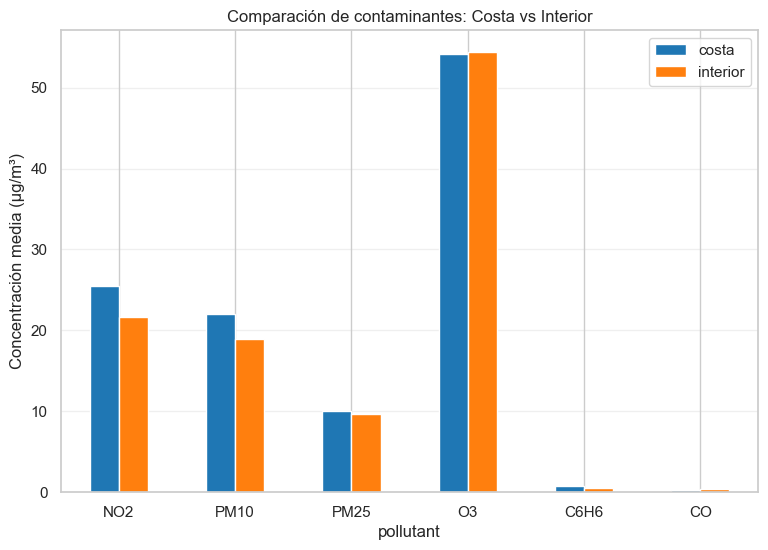

In [102]:
# Gráfico de barras comparando costa vs interior

media_comparada.plot(kind="bar", figsize=(9,6), color=["#1f77b4","#ff7f0e"])
plt.title("Comparación de contaminantes: Costa vs Interior")
plt.ylabel("Concentración media (µg/m³)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()


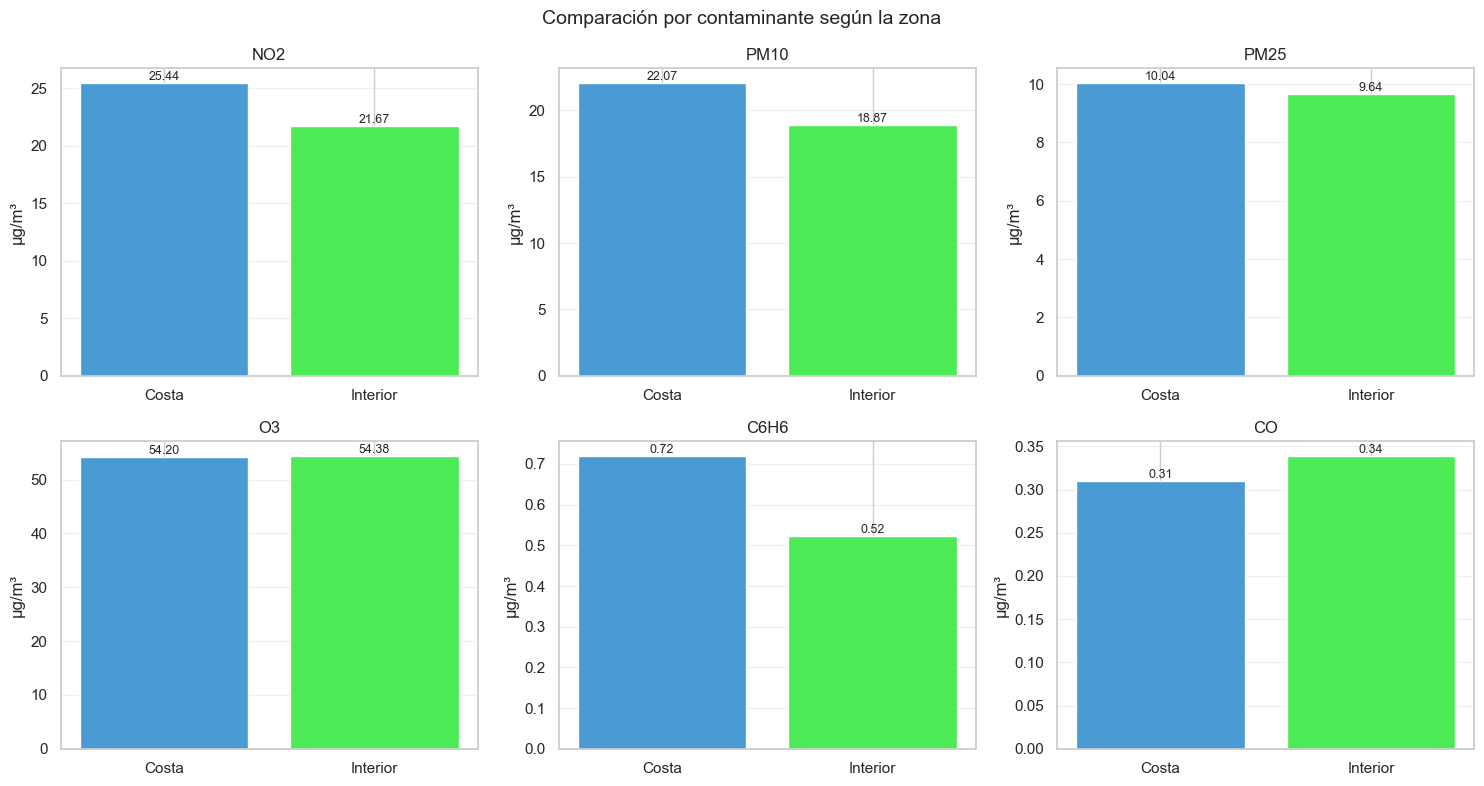

In [128]:
# Gráficos individuales por contaminante

fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

contaminantes = ["NO2","PM10","PM25","O3","C6H6","CO"]

for i, cont in enumerate(contaminantes):

    # Guardamos las barras en 'bars'
    bars = axes[i].bar(
        ["Costa","Interior"],
        [media_comparada.loc[cont,"costa"], media_comparada.loc[cont,"interior"]],
        color=["#4a9ad4","#4ceb56"]
    )

    # Añadir etiquetas encima de cada barra
    for bar in bars:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    axes[i].set_title(cont)
    axes[i].set_ylabel("µg/m³")
    axes[i].grid(axis="y", alpha=0.3)

plt.suptitle("Comparación por contaminante según la zona", fontsize=14)
plt.tight_layout()
plt.show()


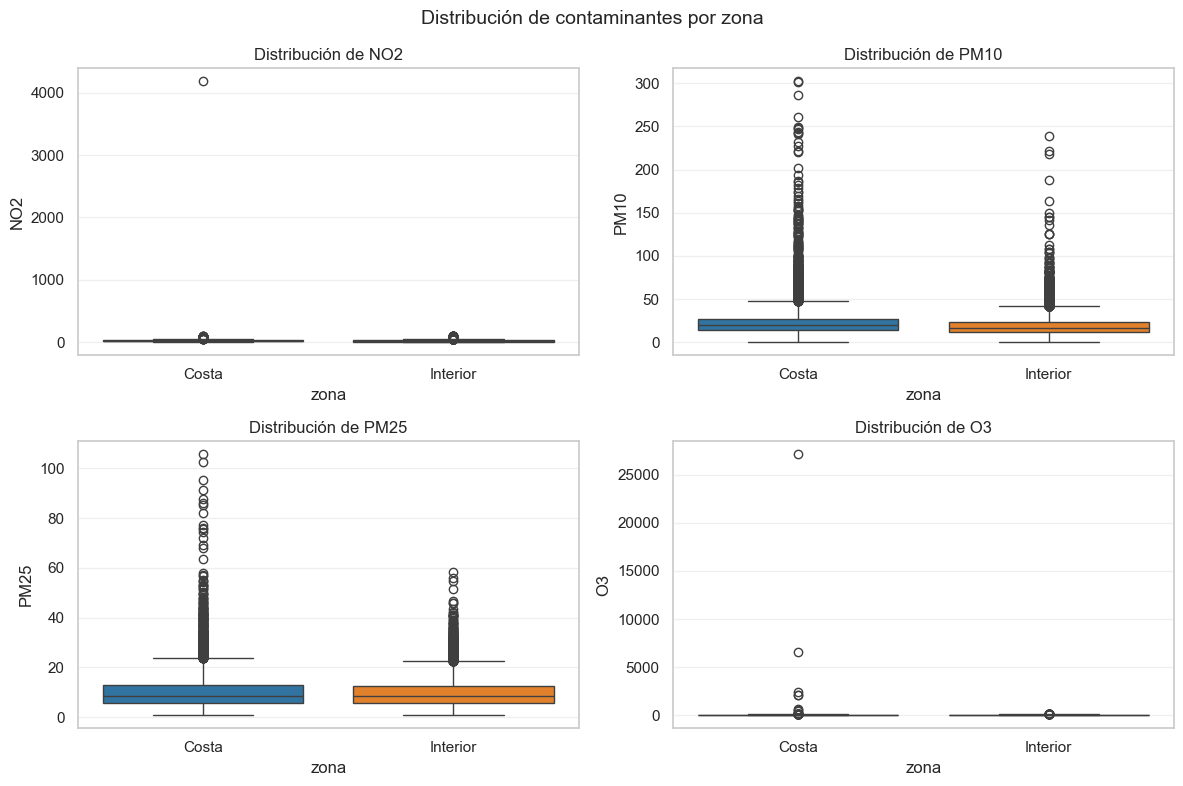

In [104]:
# Boxplots para ver la distribución real (NO2, PM10, PM25, O3)
# Preparamos el dataframe combinado
df_costa_pivot["zona"] = "Costa"
df_interior_pivot["zona"] = "Interior"

df_comparacion = pd.concat([df_costa_pivot, df_interior_pivot], ignore_index=True)

# Eliminamos posibles duplicados en el índice
df_comparacion = df_comparacion.reset_index(drop=True)

# Lista de contaminantes a graficar
contaminantes = ["NO2", "PM10", "PM25", "O3"]

# Gráficos
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, cont in zip(axes, contaminantes):
    sns.boxplot(
        data=df_comparacion,
        x="zona",
        y=cont,
        hue="zona",
        palette={"Costa": "#1f77b4", "Interior": "#ff7f0e"},
        legend=False,
        ax=ax
    )
    ax.set_title(f"Distribución de {cont}")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Distribución de contaminantes por zona", fontsize=14)
plt.tight_layout()
plt.show()


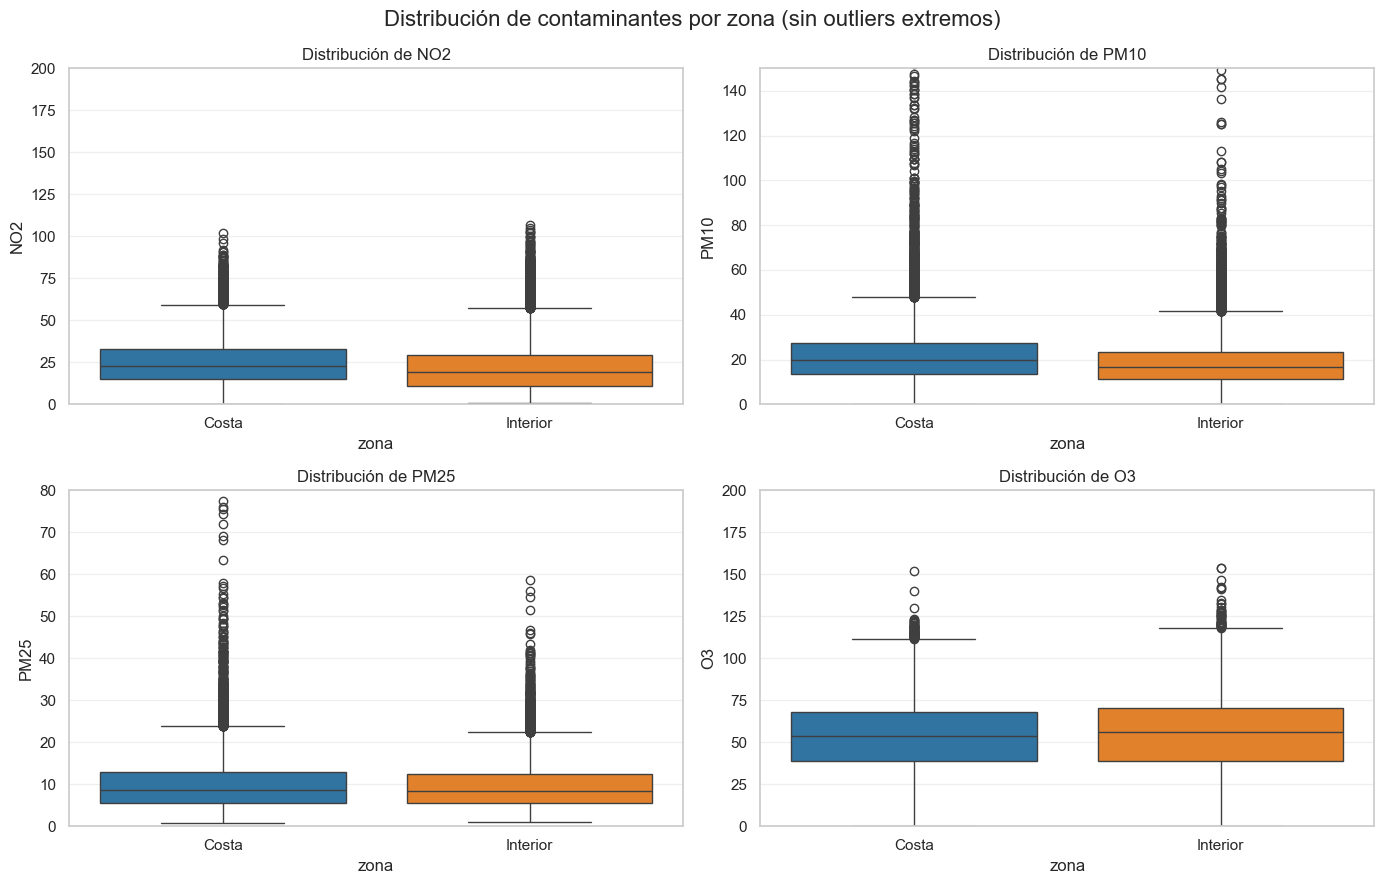

In [ ]:
# BOXPLOTS MEJORADOS PARA VER LA DISTRIBUCIÓN REAL

# Preparamos el dataframe combinado
df_costa_pivot["zona"] = "Costa"
df_interior_pivot["zona"] = "Interior"

df_comparacion = pd.concat([df_costa_pivot, df_interior_pivot], ignore_index=True)
df_comparacion = df_comparacion.reset_index(drop=True)

# Lista de contaminantes a graficar
contaminantes = ["NO2", "PM10", "PM25", "O3"]

# Límites razonables para visualizar sin que los outliers aplasten la escala
limites = {
    "NO2": 200,
    "PM10": 150,
    "PM25": 80,
    "O3": 200
}

# Gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, cont in zip(axes, contaminantes):
    sns.boxplot(
        data=df_comparacion,
        x="zona",
        y=cont,
        hue="zona",
        palette={"Costa": "#1f77b4", "Interior": "#ff7f0e"},
        legend=False,
        ax=ax
    )
    ax.set_title(f"Distribución de {cont}", fontsize=12)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, limites[cont])  # <<< LÍMITE PARA VER BIEN LA DISTRIBUCIÓN

plt.suptitle("Distribución de contaminantes por zona (sin outliers extremos)", fontsize=16)
plt.tight_layout()
plt.show()


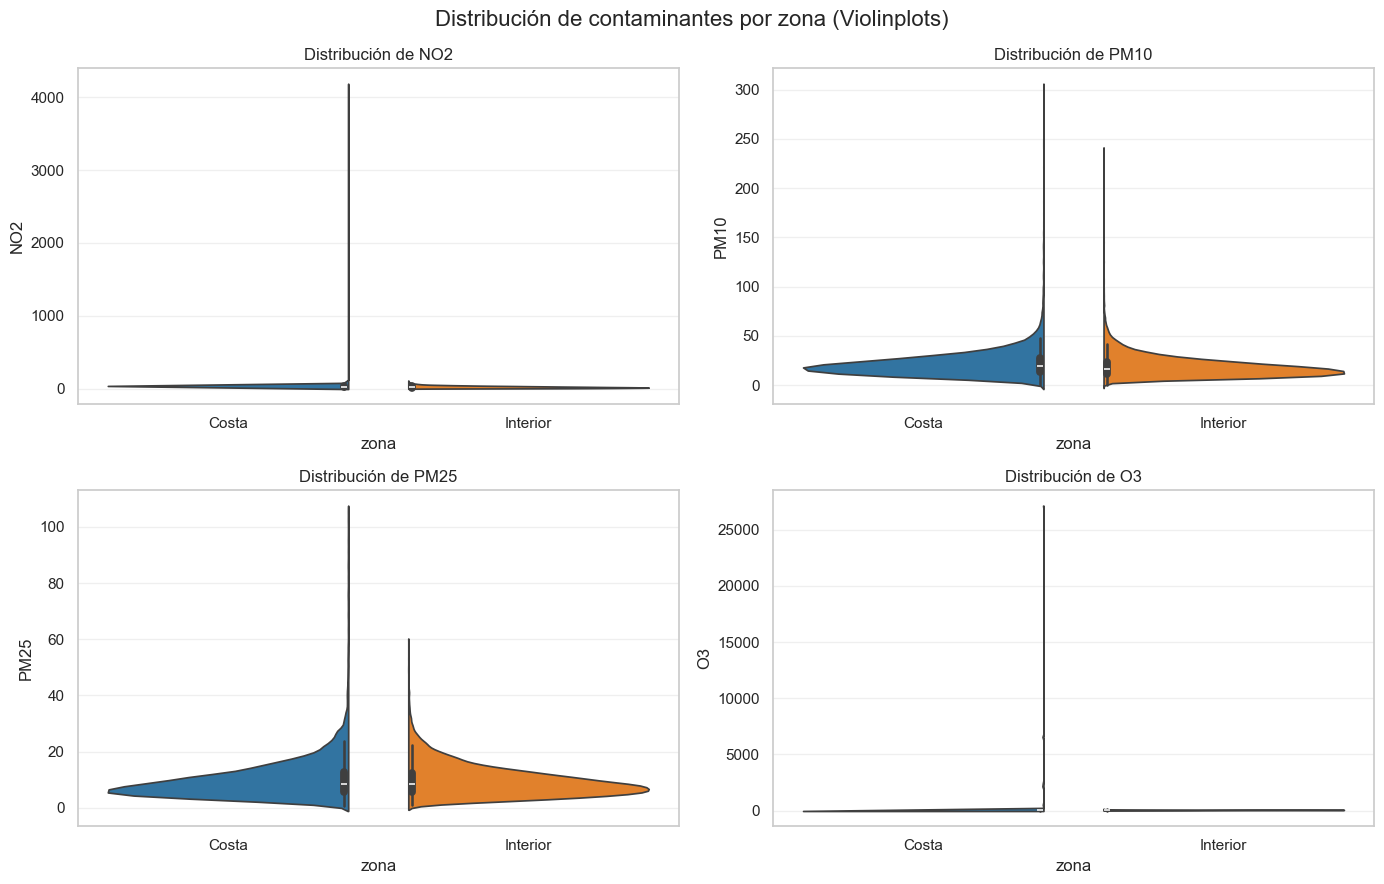

In [106]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, cont in zip(axes, ["NO2","PM10","PM25","O3"]):
    sns.violinplot(
        data=df_comparacion,
        x="zona",
        y=cont,
        hue="zona",
        palette={"Costa": "#1f77b4", "Interior": "#ff7f0e"},
        split=True,
        legend=False,
        ax=ax
    )
    ax.set_title(f"Distribución de {cont}")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Distribución de contaminantes por zona (Violinplots)", fontsize=16)
plt.tight_layout()
plt.show()


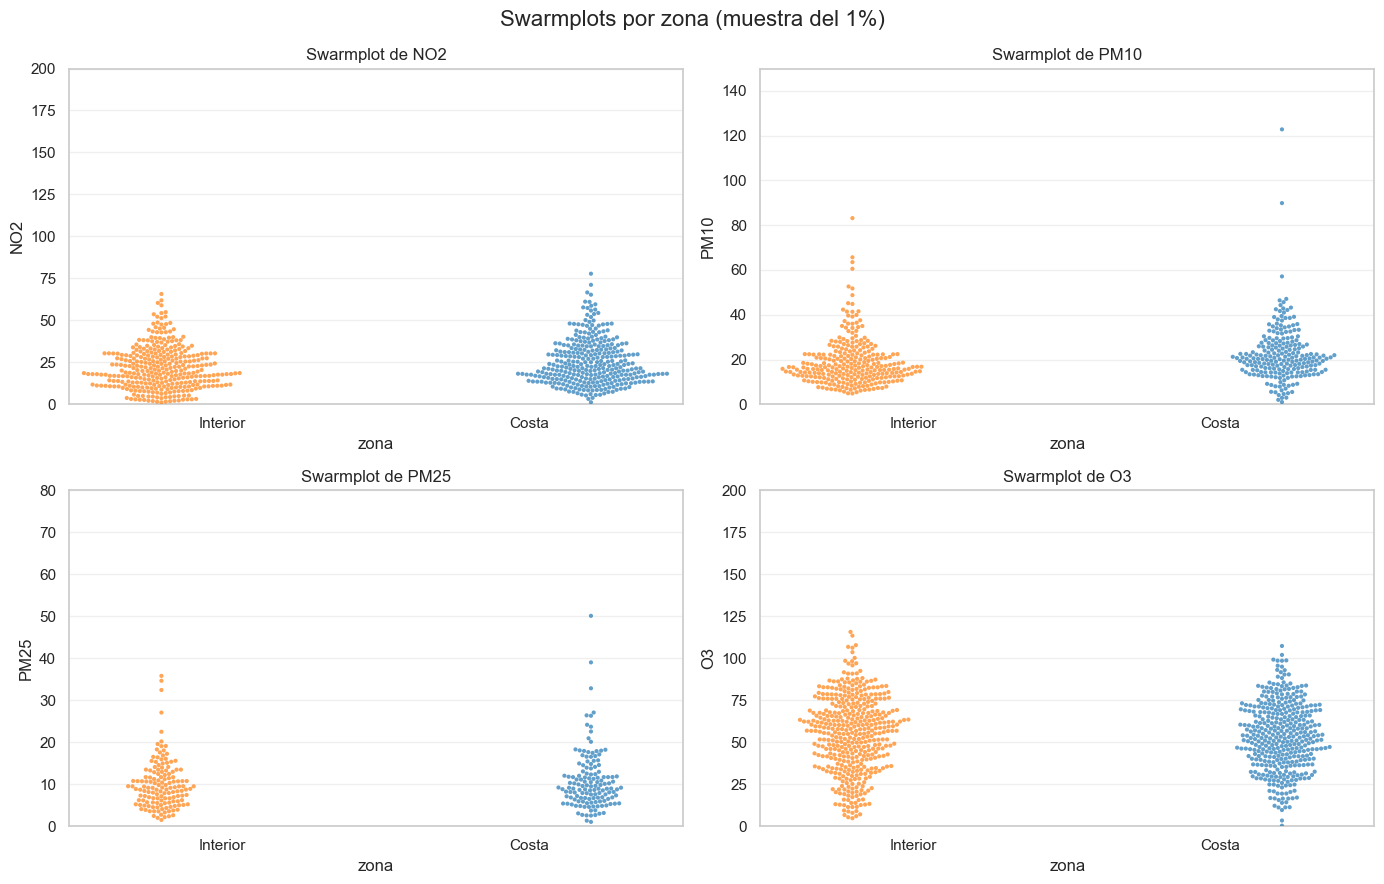

In [ ]:
# SWARMPLOTS CON MUESTRA PARA QUE NO TARDE


# Creamos una muestra del 1% para que el gráfico sea manejable
df_sample = df_comparacion.sample(frac=0.01, random_state=42)

contaminantes = ["NO2", "PM10", "PM25", "O3"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, cont in zip(axes, contaminantes):
    sns.swarmplot(
        data=df_sample,
        x="zona",
        y=cont,
        hue="zona",
        palette={"Costa": "#1f77b4", "Interior": "#ff7f0e"},
        dodge=True,
        size=3,
        alpha=0.7,
        ax=ax
    )
    ax.set_title(f"Swarmplot de {cont}")
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, limites[cont])  # Usamos los límites que ya definimos

plt.suptitle("Swarmplots por zona (muestra del 1%)", fontsize=16)
plt.tight_layout()
plt.show()


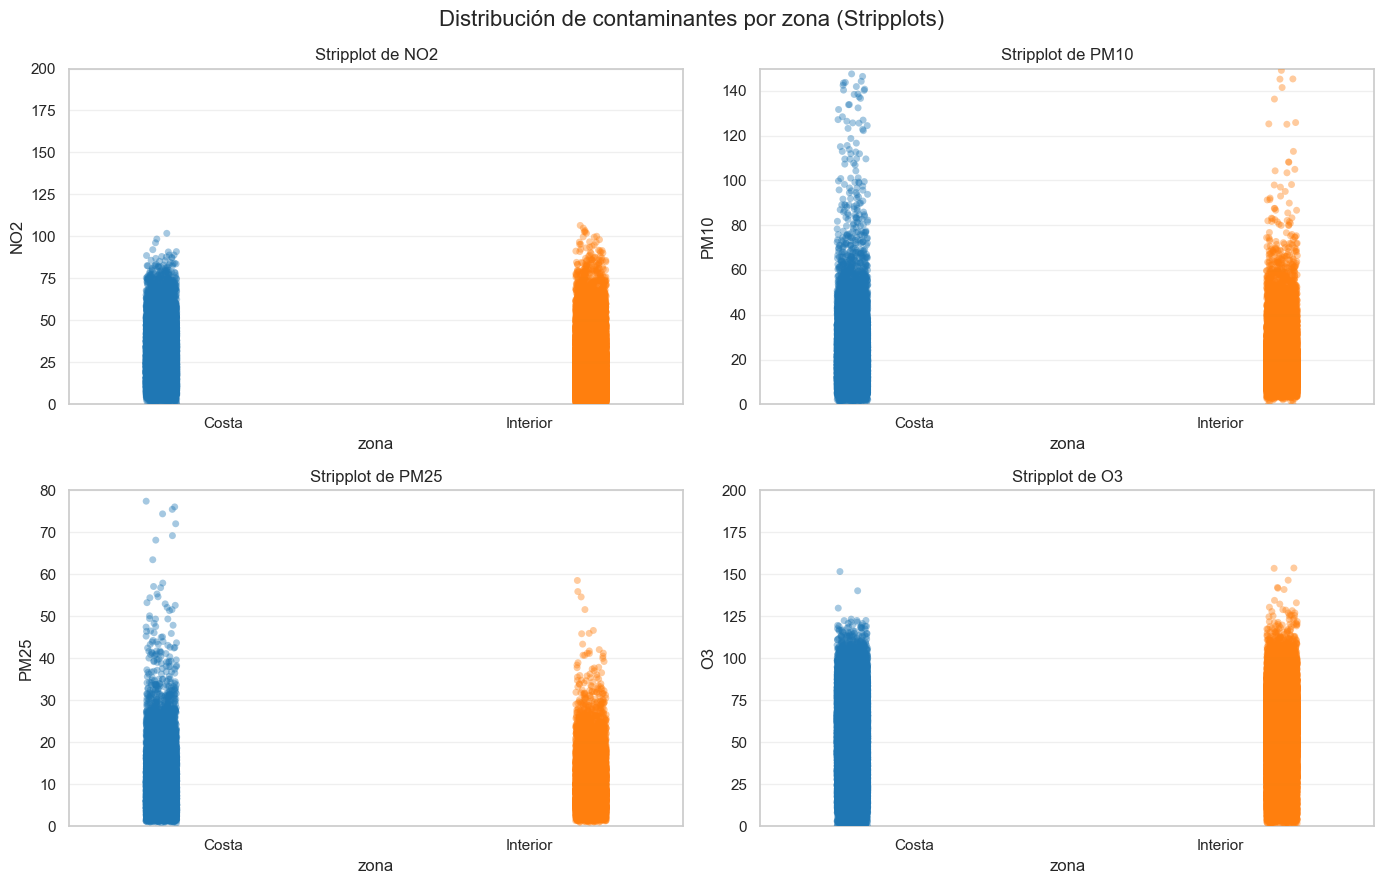

In [108]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, cont in zip(axes, ["NO2","PM10","PM25","O3"]):
    sns.stripplot(
        data=df_comparacion,
        x="zona",
        y=cont,
        hue="zona",
        palette={"Costa": "#1f77b4", "Interior": "#ff7f0e"},
        dodge=True,
        alpha=0.4,
        ax=ax
    )
    ax.set_title(f"Stripplot de {cont}")
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, limites[cont])

plt.suptitle("Distribución de contaminantes por zona (Stripplots)", fontsize=16)
plt.tight_layout()
plt.show()


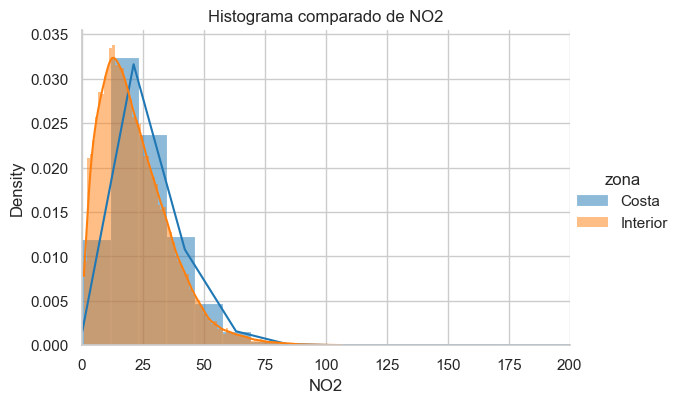

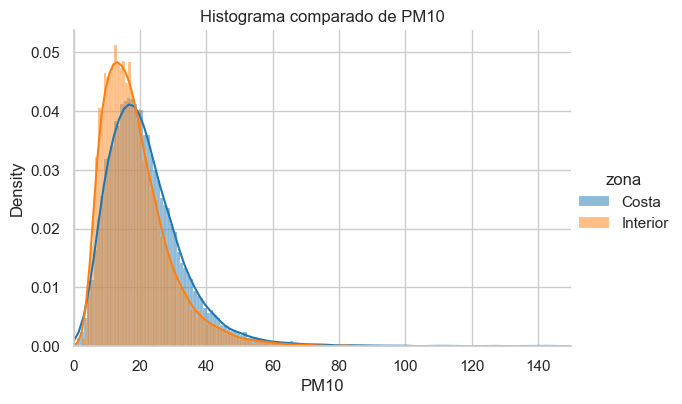

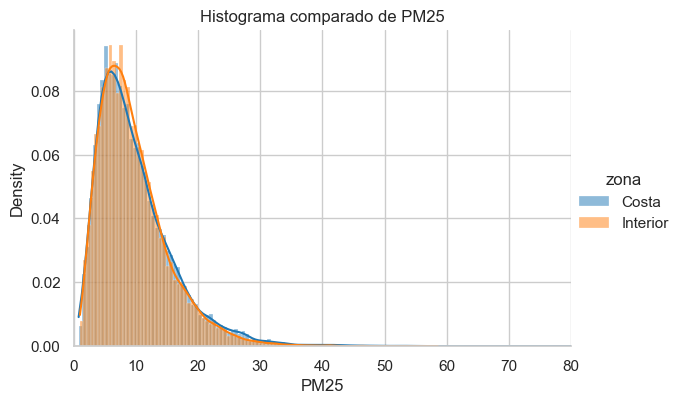

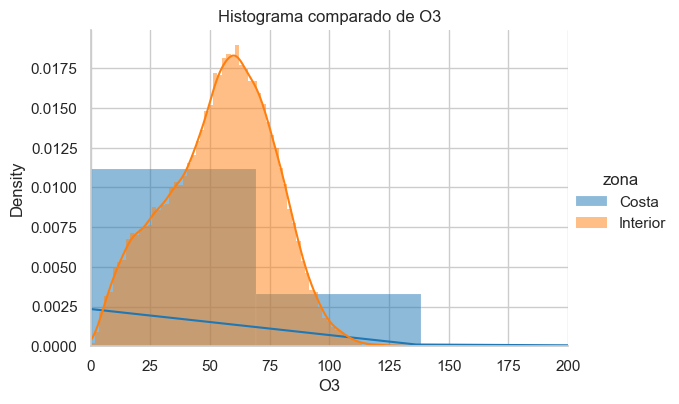

In [109]:
for cont in ["NO2","PM10","PM25","O3"]:
    g = sns.FacetGrid(df_comparacion, hue="zona", height=4, aspect=1.5,
                      palette={"Costa": "#1f77b4", "Interior": "#ff7f0e"})
    g.map(sns.histplot, cont, kde=True, stat="density", common_norm=False)
    g.add_legend()
    plt.title(f"Histograma comparado de {cont}")
    plt.xlim(0, limites[cont])
    plt.show()


**H3 — Las estaciones urbanas y de tráfico presentan mayores niveles de contaminación**  
Las estaciones clasificadas como tráfico y urbano deberían registrar concentraciones más altas que las estaciones rurales o de fondo.

In [115]:
df_pollutants_stations.head()

,date,Samplingpoint,Value,NatCode,Year,Air Pollutant,Air Quality Station EoI Code,Air Quality Station Name,Sampling Point Id,Longitude,Latitude,Municipality,Air Quality Station Area,Air Quality Station Type,Altitude,Main Emission Sources,pollutant,year
0,2011-01-01,ES/SP_09059006_9_49,10.956522,09059006,2025,SO2,ES1443A,BURGOS 4,SP_09059006_1_38,-3.63611,42.33611,BURGOS,urban,background,929.0,"Land use, land use change and forestry",PM25,2011
1,2011-01-01,ES/SP_28007004_9_49,19.739130,28007004,2025,NOX as NO2,ES1890A,ALCORCÓN,SP_28007004_12_8,-3.83370,40.34190,ALCORCÓN,urban,background,693.0,NaN,PM25,2011
2,2011-01-01,ES/SP_28148004_9_49,14.409091,28148004,2025,PM10,ES1752A,TORREJON DE ARDOZ,SP_28148004_10_49,-3.47760,40.44950,TORREJÓN DE ARDOZ,suburban,background,581.0,NaN,PM25,2011
3,2011-01-02,ES/SP_09059006_9_49,4.500000,09059006,2025,SO2,ES1443A,BURGOS 4,SP_09059006_1_38,-3.63611,42.33611,BURGOS,urban,background,929.0,"Land use, land use change and forestry",PM25,2011
4,2011-01-02,ES/SP_28007004_9_49,9.291667,28007004,2025,NOX as NO2,ES1890A,ALCORCÓN,SP_28007004_12_8,-3.83370,40.34190,ALCORCÓN,urban,background,693.0,NaN,PM25,2011


In [ ]:
'''HIPÓTESIS 3
Las estaciones urbanas presentan mayores niveles de contaminación que las estaciones suburbanas y rurales.”

Esto tiene sentido teórico porque:

Las estaciones urbanas suelen estar cerca del tráfico, industria ligera, calefacciones, etc.

Las estaciones suburbanas tienen menos densidad de tráfico.

Las estaciones rurales suelen medir fondo regional, lejos de fuentes directas.
'''

'HIPÓTESIS 3\n“Las estaciones urbanas presentan mayores niveles de contaminación que las estaciones suburbanas y rurales.”\n\nEsto tiene sentido teórico porque:\n\nLas estaciones urbanas suelen estar cerca del tráfico, industria ligera, calefacciones, etc.\n\nLas estaciones suburbanas tienen menos densidad de tráfico.\n\nLas estaciones rurales suelen medir fondo regional, lejos de fuentes directas.'

In [120]:
# Filtrar y preparar los datos
df = df_pollutants_stations.copy()

# Nos quedamos solo con urban y rural
df = df[df["Air Quality Station Area"].isin(["urban", "rural"])]

# Eliminamos valores negativos
df = df[df["Value"] >= 0]

# Pivot para tener un valor por día y estación
df_area_pivot = df.pivot_table(
    index=["date", "Municipality", "Air Quality Station Area"],
    columns="pollutant",
    values="Value",
    aggfunc="mean"
).reset_index()


df_area_pivot.head()


pollutant,date,Municipality,Air Quality Station Area,C6H6,CO,NO2,O3,PM10,PM25,SO2
0,2011-01-01,AGULLANA,rural,NaN,NaN,NaN,45.916667,NaN,NaN,NaN
1,2011-01-01,AGÜIMES,urban,NaN,NaN,NaN,73.791667,NaN,NaN,NaN
2,2011-01-01,AIA,rural,NaN,NaN,NaN,59.608696,NaN,NaN,NaN
3,2011-01-01,ALCALÁ DE GUADAIRA,urban,NaN,NaN,NaN,43.791667,NaN,NaN,NaN
4,2011-01-01,ALCALÁ DE HENARES,urban,NaN,NaN,NaN,18.625000,NaN,NaN,NaN


In [118]:
# Calcular medias por tipo de estación

media_area = df_area_pivot.groupby("Air Quality Station Area")[["NO2","PM10","PM25","O3"]].mean()
media_area



pollutant,NO2,PM10,PM25,O3
Air Quality Station Area,,,,
rural,6.367211,21.156853,7.690008,67.343113
urban,21.893727,23.637663,9.471226,54.415541


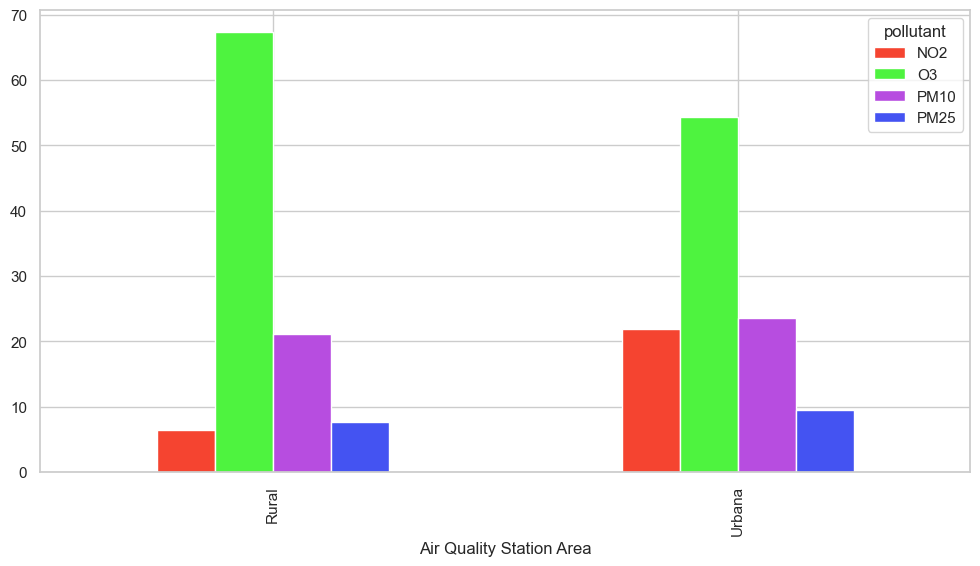

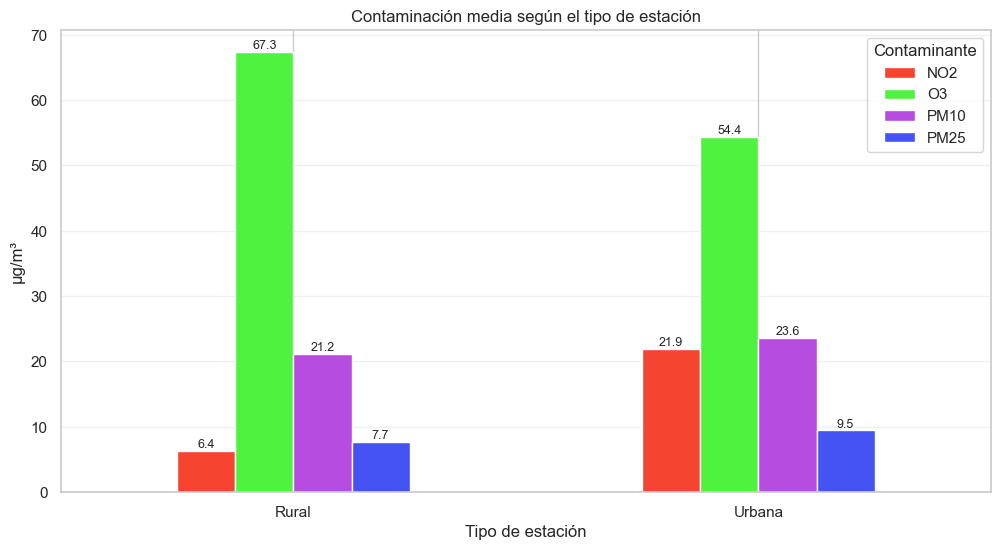

In [125]:
# GRÁFICO
# Diccionario de colores
colores = {
    "NO2": "#F54430",
    "O3": "#4EF33F",
    "PM10": "#B74DE0",
    "PM25": "#4453F2",
    "SO2": "#E1359F",
    "CO": "#D8551C"
}

# Seleccionamos solo los contaminantes que existan en tu pivot
contaminantes = [c for c in colores.keys() if c in media_area.columns]

# Renombrar índices del dataframe
media_area_renombrada = media_area.rename(index={
    "urban": "Urbana","rural": "Rural"})

# Crear gráfico
media_area_renombrada[contaminantes].plot(
    kind="bar",
    figsize=(12,6),
    color=[colores[c] for c in contaminantes])

# Añadir valores encima de cada barra
ax = media_area_renombrada[contaminantes].plot(
    kind="bar",
    figsize=(12,6),
    color=[colores[c] for c in contaminantes]
)

# Añadir etiquetas manualmente recorriendo los containers
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if not pd.isna(height):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f"{height:.1f}",
                ha="center",
                va="bottom",
                fontsize=9
            )


plt.title("Contaminación media según el tipo de estación")
plt.ylabel("µg/m³")
plt.xlabel("Tipo de estación")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Contaminante")
plt.show()


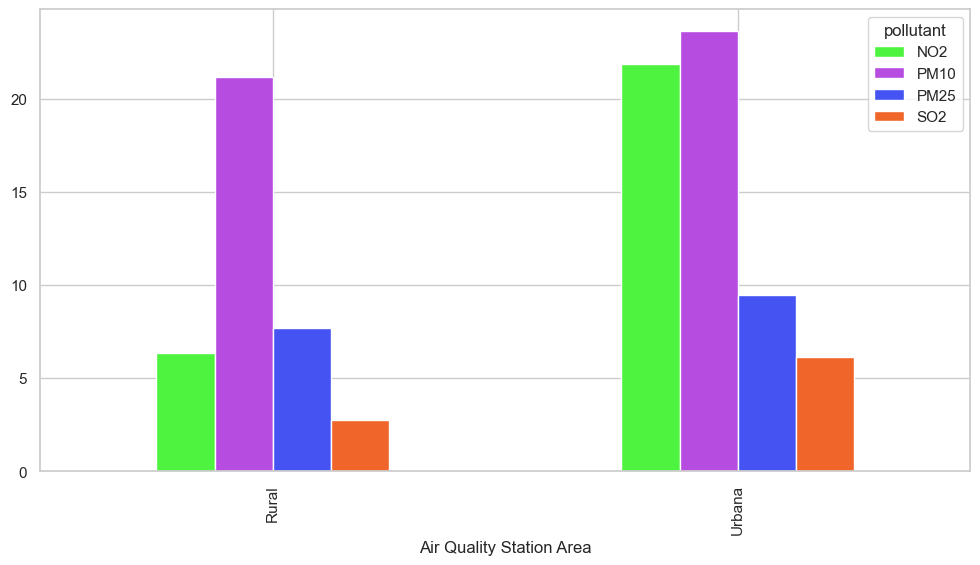

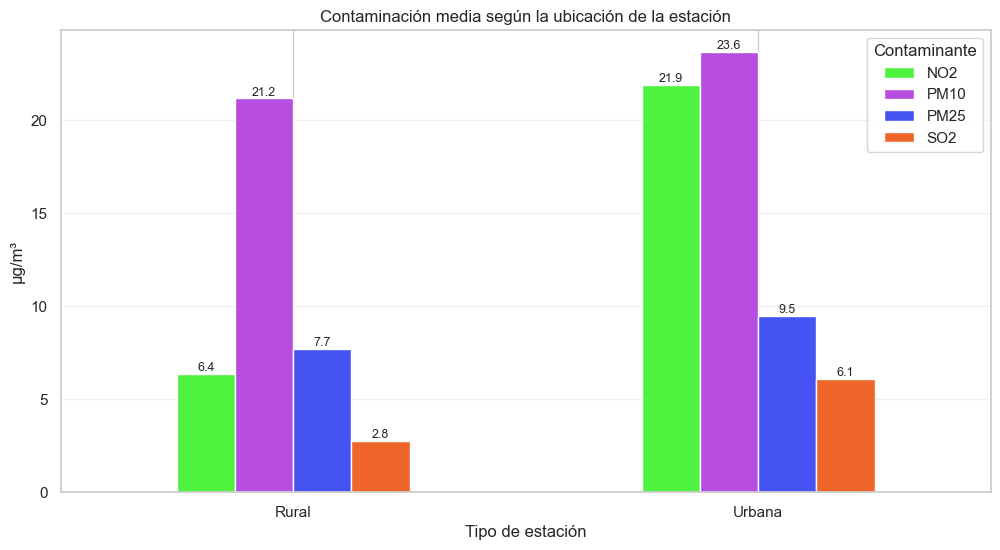

In [129]:
# Calcular medias por tipo de estación

df_area_pivot = df.pivot_table(
    index=["date", "Municipality", "Air Quality Station Area"],
    columns="pollutant",
    values="Value",
    aggfunc="mean"
).reset_index()

media_area = df_area_pivot.groupby("Air Quality Station Area")[["PM25","PM10", "NO2","SO2", "C6H6"]].mean()
media_area


# GRÁFICO
# Diccionario de colores
colores_2 = {
    "NO2": "#4EF33F",
    "O3": "#4EF33F",
    "PM10": "#B74DE0",
    "PM25": "#4453F2",
    "SO2": "#F06529",
    "CO": "#D8551C"
}

# Seleccionamos solo los contaminantes que existan en tu pivot
contaminantes = [c for c in colores_2.keys() if c in media_area.columns]

# Renombrar índices del dataframe
media_area_renombrada = media_area.rename(index={
    "urban": "Urbana","rural": "Rural"})

# Crear gráfico
media_area_renombrada[contaminantes].plot(
    kind="bar",
    figsize=(12,6),
    color=[colores_2[c] for c in contaminantes])

# Añadir valores encima de cada barra
ax = media_area_renombrada[contaminantes].plot(
    kind="bar",
    figsize=(12,6),
    color=[colores_2[c] for c in contaminantes]
)

# Añadir etiquetas manualmente recorriendo los containers
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if not pd.isna(height):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f"{height:.1f}",
                ha="center",
                va="bottom",
                fontsize=9
            )


plt.title("Contaminación media según la ubicación de la estación")
plt.ylabel("µg/m³")
plt.xlabel("Tipo de estación")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Contaminante")
plt.show()


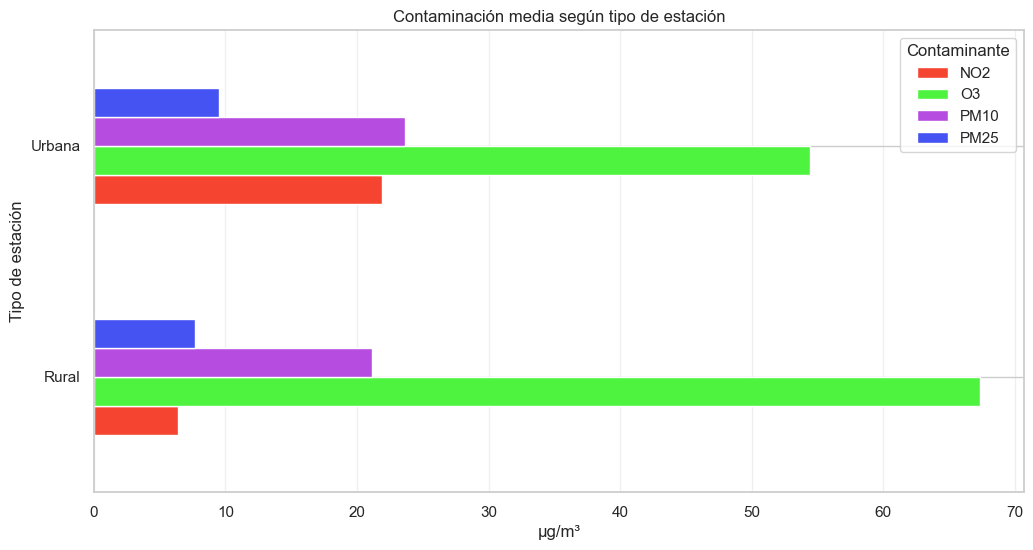

In [103]:
# Crear gráfico horizontal
media_area_renombrada[contaminantes].plot(
    kind="barh",
    figsize=(12,6),
    color=[colores[c] for c in contaminantes]
)

plt.title("Contaminación media según tipo de estación")
plt.xlabel("µg/m³")
plt.ylabel("Tipo de estación")   # ← Cambiado
plt.grid(axis="x", alpha=0.3)
plt.legend(title="Contaminante")
plt.show()



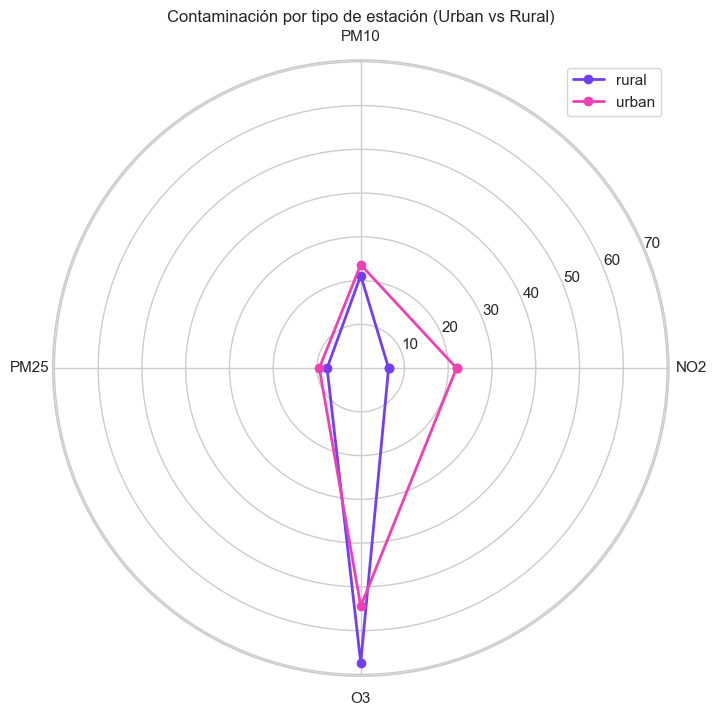

In [98]:
colores_area = {
    "urban":    "#EF40B5",
    "rural":    "#723FF3"}

categorias = ["NO2","PM10","PM25","O3"]
N = len(categorias)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8,8))

for area in media_area.index:
    valores = media_area.loc[area, categorias].tolist()
    valores += valores[:1]

    plt.polar(
        angles,
        valores,
        marker="o",
        linewidth=2,
        color=colores_area[area],
        label=area
    )

plt.xticks(angles[:-1], categorias)
plt.title("Contaminación por tipo de estación (Urban vs Rural)")
plt.legend()
plt.show()




**H4 — El ozono (O₃) aumenta en verano debido a procesos fotoquímicos**  
El ozono troposférico depende de la radiación solar, por lo que se espera observar un patrón estacional claro con valores más altos en verano.
'''

In [ ]:
'''H4 — Definición clara de la hipótesis
H4 plantea que el ozono troposférico (O₃) presenta un comportamiento estacional marcado, con concentraciones significativamente más altas durante el verano debido a los procesos fotoquímicos que dependen de la radiación solar.

En otras palabras:

El O₃ no es un contaminante primario, sino secundario.

Se forma cuando hay mucha luz solar, temperaturas altas y precursores (NO₂ y compuestos orgánicos volátiles).

Por tanto, debería aumentar en los meses de junio-julio-agosto.

Y debería ser más bajo en invierno, cuando hay menos radiación y menos formación fotoquímica.'''

In [23]:
# Preparar datos de ozono y añadir mes/estación

df = df_pollutants_stations.copy()

# Nos quedamos solo con O3
df_o3 = df[df["pollutant"] == "O3"].copy()

# Aseguramos tipo fecha
df_o3["date"] = pd.to_datetime(df_o3["date"])

# Extraemos mes y año
df_o3["month"] = df_o3["date"].dt.month
df_o3["year"] = df_o3["date"].dt.year

# Función para asignar estación
def asignar_estacion(m):
    if m in [12, 1, 2]:
        return "invierno"
    elif m in [3, 4, 5]:
        return "primavera"
    elif m in [6, 7, 8]:
        return "verano"
    else:
        return "otoño"

df_o3["season"] = df_o3["month"].apply(asignar_estacion)


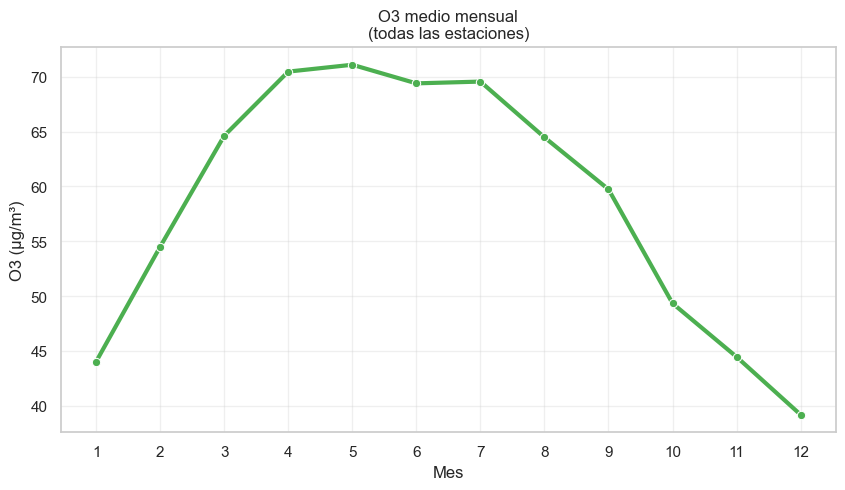

In [33]:
# Media de O₃ por mes (patrón fino)

o3_mes = df_o3.groupby("month")["Value"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=o3_mes, x="month", y="Value", marker="o", color="#4CAF50", linewidth=3)
plt.xticks(range(1,13))
plt.title("O3 medio mensual\n(todas las estaciones)")
plt.xlabel("Mes")
plt.ylabel("O3 (µg/m³)")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
'''
Gráfico mensual (enero-diciembre)
El patrón es clarísimo:

Enero-ebrero → valores bajos (~40-45)

Subida progresiva en marzo

Pico en abril-mayo (~70-72 µg/m³)

Valores altos mantenidos en junio-julio-agosto

Descenso en otoño

Mínimos otra vez en diciembre

'''

C:\Users\titea\AppData\Local\Temp\ipykernel_20800\1373442134.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=o3_estacion,


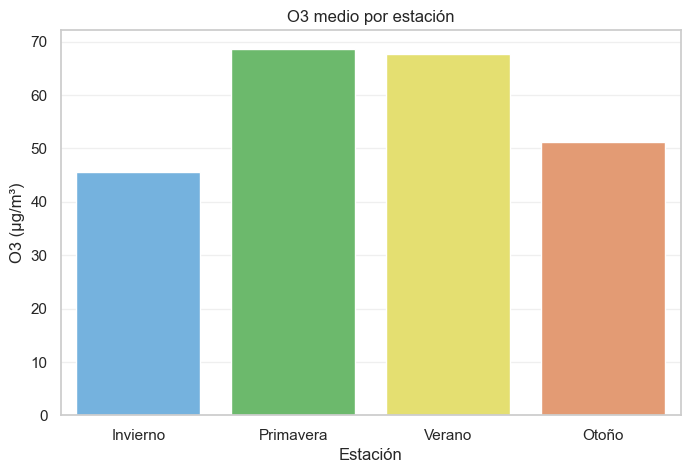

In [35]:
# Diccionario de colores por estación
colores_estaciones = {"Invierno": "#64b5ef",
    "Primavera": "#5fc65f",
    "Verano": "#f7f15e",
    "Otoño": "#f69561"}

o3_estacion = df_o3.groupby("season")["Value"].mean().reindex(
    ["invierno","primavera","verano","otoño"]
).reset_index()


plt.figure(figsize=(8,5))
sns.barplot(data=o3_estacion,
    x=o3_estacion["season"].str.capitalize(),
    y="Value",
    palette=colores_estaciones)

plt.title("O3 medio por estación")
plt.xlabel("Estación")
plt.ylabel("O3 (µg/m³)")
plt.grid(axis="y", alpha=0.3)
plt.show()


In [ ]:
'''Gráfico por estaciones

Primavera ≈ 68

Verano ≈ 67

Otoño ≈ 51

Invierno ≈ 45

Primavera y verano son claramente las estaciones con más O₃.
Invierno es la más baja, como era esperable.

Aunque el máximo absoluto cae en primavera (muy típico en España por la combinación de radiación + menos
titulación por NO), el verano sigue siendo una estación de valores altos, y el patrón global es inequívocamente fotoquímico.

'''